In [11]:
# Cell [0] - IMPORTS & GLOBAL SETUP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Supaya hasil reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8")
%matplotlib inline


In [13]:
# Cell [1] - PATH & CEK SHEET

path = r"C:\Users\totti\OneDrive\Dokumen\Machine Learning\New\Gold_Silver_Forecasting - New.xlsx"
print("Path file:", path)

# cek sheet yang tersedia
xls = pd.ExcelFile(path)
print("Sheet di workbook:")
print(xls.sheet_names)


Path file: C:\Users\totti\OneDrive\Dokumen\Machine Learning\New\Gold_Silver_Forecasting - New.xlsx
Sheet di workbook:
['Sheet1']


In [15]:
# Cell [2] - LOAD DATA UTAMA

df_raw = pd.read_excel(
    path,
    sheet_name=0,          # kalau perlu ganti ke nama sheet spesifik
    parse_dates=["DATE"]   # pastikan kolom tanggal bernama DATE
)

# sort berdasarkan tanggal & jadikan index
df_raw = df_raw.sort_values("DATE").set_index("DATE")

print("Shape df_raw:", df_raw.shape)
df_raw.head()


Shape df_raw: (13027, 51)


,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CLOSE,GOLD_CHANGE_%,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CLOSE,SILVER_CHANGE_%,...,REAL_YIELD,GOLD_DAILY_RANGE,GOLD_SILVER_RATIO,REAL_INTEREST_RATE,GOLD_VOLATILITY_30D,COPPER_GOLD_RATIO,WTI_GOLD_RATIO,GOLD_RSI_14,GOLD_MACD,CPI_YOY
DATE,,,,,,,,,,,,,,,,,,,,,
1990-01-01,404.85,403.05,403.05,403.05,0.83,5.21,5.22,5.21,5.22,0.97,...,3.333,0.0,77.212644,3.333,0.012172,0.002640,0.054137,33.294931,0.847403,4.6
1990-01-02,403.85,399.45,399.45,399.45,-0.89,5.18,5.19,5.18,5.19,-0.57,...,3.333,0.0,76.965318,3.333,0.012063,0.002659,0.057304,41.642651,0.210248,4.6
1990-01-03,399.60,394.75,394.75,394.75,-1.18,5.17,5.17,5.17,5.17,-0.39,...,3.333,0.0,76.353965,3.333,0.011832,0.002778,0.059987,30.694444,-0.666273,4.6
1990-01-04,399.45,399.05,399.05,399.05,1.09,5.27,5.28,5.27,5.28,2.13,...,3.333,0.0,75.577652,3.333,0.011988,0.002720,0.058664,29.915730,-1.002393,4.6
1990-01-05,407.45,406.35,406.35,406.35,1.83,5.32,5.33,5.32,5.33,0.95,...,3.333,0.0,76.238274,3.333,0.012050,0.002695,0.056798,42.535545,-0.671975,4.6


In [17]:
# Cell [3] - PILIH KOLOM PENTING & FILTERING

base_cols = [
    "GOLD_CLOSE",
    "SILVER_CLOSE",
    "WTI",
    "COPPER",
    "SP500",
    "VIX",
    "FED_FUNDS",
    "M2",
    "CPI_ACTUAL",
    "TREASURY_10Y",
    "REAL_YIELD",
    "REAL_INTEREST_RATE",
]

# hanya pakai kolom yang memang ada
base_cols_exist = [c for c in base_cols if c in df_raw.columns]
missing_cols = [c for c in base_cols if c not in df_raw.columns]

print("Kolom dipakai:", base_cols_exist)
print("Kolom TIDAK ditemukan:", missing_cols)

df_fe = df_raw[base_cols_exist].copy()

print("\nMissing per kolom:")
print(df_fe.isna().sum())

# drop baris yang ada NaN di kolom penting
df_fe = df_fe.dropna(how="any")

print("\nShape setelah drop NaN:", df_fe.shape)
df_fe.head()


Kolom dipakai: ['GOLD_CLOSE', 'SILVER_CLOSE', 'WTI', 'COPPER', 'SP500', 'VIX', 'FED_FUNDS', 'M2', 'CPI_ACTUAL', 'TREASURY_10Y', 'REAL_YIELD', 'REAL_INTEREST_RATE']
Kolom TIDAK ditemukan: []

Missing per kolom:
GOLD_CLOSE            0
SILVER_CLOSE          0
WTI                   0
COPPER                0
SP500                 0
VIX                   0
FED_FUNDS             0
M2                    0
CPI_ACTUAL            0
TREASURY_10Y          0
REAL_YIELD            0
REAL_INTEREST_RATE    0
dtype: int64

Shape setelah drop NaN: (13027, 12)


,GOLD_CLOSE,SILVER_CLOSE,WTI,COPPER,SP500,VIX,FED_FUNDS,M2,CPI_ACTUAL,TREASURY_10Y,REAL_YIELD,REAL_INTEREST_RATE
DATE,,,,,,,,,,,,
1990-01-01,403.05,5.22,21.82,1.0640,353.4,18.19,8.23,3166800000000,4.6,7.933,3.333,3.333
1990-01-02,399.45,5.19,22.89,1.0620,359.7,18.19,8.23,3166800000000,4.6,7.933,3.333,3.333
1990-01-03,394.75,5.17,23.68,1.0965,358.8,18.19,8.23,3166800000000,4.6,7.933,3.333,3.333
1990-01-04,399.05,5.28,23.41,1.0855,355.7,19.22,8.23,3166800000000,4.6,7.933,3.333,3.333
1990-01-05,406.35,5.33,23.08,1.0950,352.2,20.11,8.23,3166800000000,4.6,7.933,3.333,3.333


In [19]:
# Cell [4] - RETURN & VOLATILITY FEATURES (RET_1D)

df_ret = df_fe.copy()

# 1) Return masa lalu (level harga emas)
df_ret["RET_PAST_1"] = df_ret["GOLD_CLOSE"].pct_change(1)
df_ret["RET_PAST_3"] = df_ret["GOLD_CLOSE"].pct_change(3)
df_ret["RET_PAST_5"] = df_ret["GOLD_CLOSE"].pct_change(5)

# 2) Rolling volatility dari return harian
df_ret["VOL_5"]  = df_ret["RET_PAST_1"].rolling(window=5).std()
df_ret["VOL_20"] = df_ret["RET_PAST_1"].rolling(window=20).std()

# 3) TARGET: return 1 hari ke depan (forward)
df_ret["RET_1D"] = (df_ret["GOLD_CLOSE"].shift(-1) - df_ret["GOLD_CLOSE"]) / df_ret["GOLD_CLOSE"]

# 4) TARGET_PRICE: harga emas besok (untuk evaluasi level harga)
df_ret["TARGET_PRICE"] = df_ret["GOLD_CLOSE"].shift(-1)

# Buang baris yang mengandung NaN akibat shift/rolling
df_ret = df_ret.dropna(subset=[
    "RET_PAST_1", "RET_PAST_3", "RET_PAST_5",
    "VOL_5", "VOL_20", "RET_1D", "TARGET_PRICE"
])

print("Shape df_ret:", df_ret.shape)
df_ret.head()


Shape df_ret: (13006, 19)


,GOLD_CLOSE,SILVER_CLOSE,WTI,COPPER,SP500,VIX,FED_FUNDS,M2,CPI_ACTUAL,TREASURY_10Y,REAL_YIELD,REAL_INTEREST_RATE,RET_PAST_1,RET_PAST_3,RET_PAST_5,VOL_5,VOL_20,RET_1D,TARGET_PRICE
DATE,,,,,,,,,,,,,,,,,,,
1990-01-21,410.15,5.22,23.67,0.9930,339.1,22.50,8.23,3166800000000,4.6,8.239,3.639,3.639,0.000000,-0.001825,0.002199,0.006035,0.008763,-0.003657,408.65
1990-01-22,408.65,5.29,22.55,0.9875,330.4,26.70,8.23,3166800000000,4.6,8.278,3.678,3.678,-0.003657,-0.003657,-0.011610,0.002627,0.008527,0.011134,413.20
1990-01-23,413.20,5.30,21.60,0.9745,331.6,24.72,8.23,3166800000000,4.6,8.369,3.769,3.769,0.011134,0.007436,0.005597,0.005794,0.008231,0.010770,417.65
1990-01-24,417.65,5.24,21.59,0.9660,330.3,25.39,8.23,3166800000000,4.6,8.374,3.774,3.774,0.010770,0.018286,0.018286,0.006833,0.008224,0.001125,418.12
1990-01-25,418.12,5.24,22.24,0.9770,326.1,25.63,8.23,3166800000000,4.6,8.418,3.818,3.818,0.001125,0.023174,0.019432,0.006700,0.007314,0.005094,420.25


In [21]:
# Cell [5] - FEATURE EXTRACTION KALENDER

df_ret["DAY"]         = df_ret.index.day
df_ret["MONTH"]       = df_ret.index.month
df_ret["YEAR"]        = df_ret.index.year
df_ret["DAY_OF_WEEK"] = df_ret.index.dayofweek   # 0=Senin, 6=Minggu
df_ret["IS_WEEKEND"]  = (df_ret["DAY_OF_WEEK"] >= 5).astype(int)

df_ret[["GOLD_CLOSE", "RET_1D", "DAY_OF_WEEK", "IS_WEEKEND"]].head()


,GOLD_CLOSE,RET_1D,DAY_OF_WEEK,IS_WEEKEND
DATE,,,,
1990-01-21,410.15,-0.003657,6,1
1990-01-22,408.65,0.011134,0,0
1990-01-23,413.20,0.010770,1,0
1990-01-24,417.65,0.001125,2,0
1990-01-25,418.12,0.005094,3,0


In [23]:
# Cell [6] - DATA AUGMENTATION: LAG FEATURES

lag_cols = [
    "GOLD_CLOSE",
    "SILVER_CLOSE",
    "WTI",
    "COPPER",
    "SP500",
    "VIX",
    "TREASURY_10Y",
    "REAL_YIELD",
]

# pastikan kolomnya ada
lag_cols = [c for c in lag_cols if c in df_ret.columns]

lags = [1, 3, 5]

for col in lag_cols:
    for L in lags:
        df_ret[f"{col}_lag{L}"] = df_ret[col].shift(L)

# drop baris yang masih NaN karena lag
df_ret = df_ret.dropna()

print("Shape setelah lag features:", df_ret.shape)
df_ret.head()


Shape setelah lag features: (13001, 48)


,GOLD_CLOSE,SILVER_CLOSE,WTI,COPPER,SP500,VIX,FED_FUNDS,M2,CPI_ACTUAL,TREASURY_10Y,...,SP500_lag5,VIX_lag1,VIX_lag3,VIX_lag5,TREASURY_10Y_lag1,TREASURY_10Y_lag3,TREASURY_10Y_lag5,REAL_YIELD_lag1,REAL_YIELD_lag3,REAL_YIELD_lag5
DATE,,,,,,,,,,,,,,,,,,,,,
1990-01-26,420.25,5.24,22.56,0.9835,325.8,26.28,8.23,3166800000000,4.6,8.472,...,339.1,25.63,24.72,22.50,8.418,8.369,8.239,3.818,3.769,3.639
1990-01-27,420.25,5.24,22.56,0.9835,325.8,26.28,8.23,3166800000000,4.6,8.472,...,330.4,26.28,25.39,26.70,8.472,8.374,8.278,3.872,3.774,3.678
1990-01-28,420.25,5.24,22.56,0.9835,325.8,26.28,8.23,3166800000000,4.6,8.472,...,331.6,26.28,25.63,24.72,8.472,8.418,8.369,3.872,3.818,3.769
1990-01-29,419.00,5.23,22.80,0.9675,325.2,26.44,8.23,3166800000000,4.6,8.516,...,330.3,26.28,26.28,25.39,8.472,8.472,8.374,3.872,3.872,3.774
1990-01-30,418.85,5.22,22.46,0.9530,323.0,27.25,8.23,3166800000000,4.6,8.511,...,326.1,26.44,26.28,25.63,8.516,8.472,8.418,3.916,3.872,3.818


Ukuran correlation matrix: (46, 46)


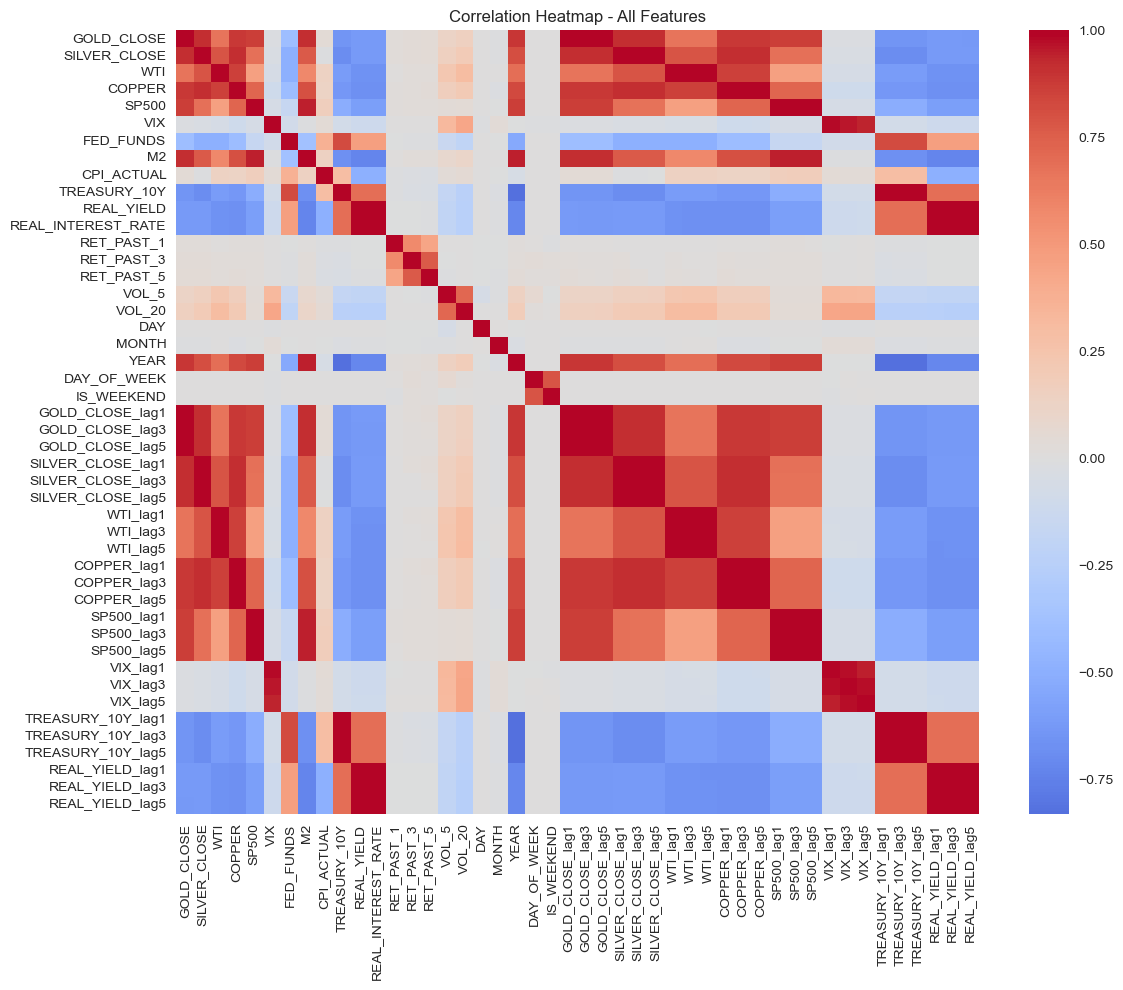

In [25]:
# Cell [7] - CORRELATION ANALYSIS

feature_cols_all = [c for c in df_ret.columns if c not in ["RET_1D", "TARGET_PRICE"]]

corr_matrix = df_ret[feature_cols_all].corr()

print("Ukuran correlation matrix:", corr_matrix.shape)

import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - All Features")
plt.tight_layout()
plt.show()


In [27]:
# Cell [8] - FEATURE SELECTION (BUANG HIGHLY CORRELATED FEATURES)

high_corr_pairs = []
threshold = 0.9

for i, col1 in enumerate(feature_cols_all):
    for col2 in feature_cols_all[i+1:]:
        corr_val = corr_matrix.loc[col1, col2]
        if abs(corr_val) > threshold:
            high_corr_pairs.append((col1, col2, corr_val))

print("Jumlah pasangan fitur dengan |corr| >", threshold, ":", len(high_corr_pairs))

to_drop = set()
for col1, col2, corr_val in high_corr_pairs:
    # buang kolom kedua secara konsisten
    if col2 not in to_drop:
        to_drop.add(col2)

print("\nFitur yang dibuang karena multikolinearitas (|corr|>0.9):")
print(sorted(to_drop))

df_fs = df_ret.drop(columns=list(to_drop))

print("\nShape sebelum FS:", df_ret.shape)
print("Shape sesudah FS:", df_fs.shape)

df_fs.head()


Jumlah pasangan fitur dengan |corr| > 0.9 : 93

Fitur yang dibuang karena multikolinearitas (|corr|>0.9):
['COPPER', 'COPPER_lag1', 'COPPER_lag3', 'COPPER_lag5', 'GOLD_CLOSE_lag1', 'GOLD_CLOSE_lag3', 'GOLD_CLOSE_lag5', 'M2', 'REAL_INTEREST_RATE', 'REAL_YIELD_lag1', 'REAL_YIELD_lag3', 'REAL_YIELD_lag5', 'SILVER_CLOSE', 'SILVER_CLOSE_lag1', 'SILVER_CLOSE_lag3', 'SILVER_CLOSE_lag5', 'SP500_lag1', 'SP500_lag3', 'SP500_lag5', 'TREASURY_10Y_lag1', 'TREASURY_10Y_lag3', 'TREASURY_10Y_lag5', 'VIX_lag1', 'VIX_lag3', 'VIX_lag5', 'WTI_lag1', 'WTI_lag3', 'WTI_lag5', 'YEAR']

Shape sebelum FS: (13001, 48)
Shape sesudah FS: (13001, 19)


,GOLD_CLOSE,WTI,SP500,VIX,FED_FUNDS,CPI_ACTUAL,TREASURY_10Y,REAL_YIELD,RET_PAST_1,RET_PAST_3,RET_PAST_5,VOL_5,VOL_20,RET_1D,TARGET_PRICE,DAY,MONTH,DAY_OF_WEEK,IS_WEEKEND
DATE,,,,,,,,,,,,,,,,,,,
1990-01-26,420.25,22.56,325.8,26.28,8.23,4.6,8.472,3.872,0.005094,0.017062,0.024625,0.006341,0.007349,0.000000,420.25,26,1,4,0
1990-01-27,420.25,22.56,325.8,26.28,8.23,4.6,8.472,3.872,0.000000,0.006225,0.028386,0.005220,0.007349,0.000000,420.25,27,1,5,1
1990-01-28,420.25,22.56,325.8,26.28,8.23,4.6,8.472,3.872,0.000000,0.005094,0.017062,0.004623,0.006788,-0.002974,419.00,28,1,6,1
1990-01-29,419.00,22.80,325.2,26.44,8.23,4.6,8.516,3.916,-0.002974,-0.002974,0.003232,0.002914,0.006683,-0.000358,418.85,29,1,0,0
1990-01-30,418.85,22.46,323.0,27.25,8.23,4.6,8.511,3.911,-0.000358,-0.003331,0.001746,0.002929,0.006017,-0.017071,411.70,30,1,1,0


In [29]:
# Cell [9] - DEFINE X & y UNTUK RET_1D

target_col_ret   = "RET_1D"
target_col_price = "TARGET_PRICE"

feature_cols_ret = [c for c in df_fs.columns if c not in [target_col_ret, target_col_price]]

X_all_ret   = df_fs[feature_cols_ret]
y_all_ret   = df_fs[target_col_ret]
y_all_price = df_fs[target_col_price]

print("Jumlah fitur:", len(feature_cols_ret))
print("X_all_ret:", X_all_ret.shape)
print("y_all_ret:", y_all_ret.shape)
print("y_all_price:", y_all_price.shape)


Jumlah fitur: 17
X_all_ret: (13001, 17)
y_all_ret: (13001,)
y_all_price: (13001,)


In [31]:
# Cell [10] - TIME-BASED SPLIT (70% train, 15% val, 15% test)

n = len(X_all_ret)
train_size = int(0.70 * n)
val_size   = int(0.15 * n)
test_size  = n - train_size - val_size

print("Total data :", n)
print("Train size:", train_size)
print("Val size  :", val_size)
print("Test size :", test_size)

X_train_ret = X_all_ret.iloc[:train_size]
X_val_ret   = X_all_ret.iloc[train_size:train_size + val_size]
X_test_ret  = X_all_ret.iloc[train_size + val_size:]

y_train_ret = y_all_ret.iloc[:train_size]
y_val_ret   = y_all_ret.iloc[train_size:train_size + val_size]
y_test_ret  = y_all_ret.iloc[train_size + val_size:]

y_train_price = y_all_price.iloc[:train_size]
y_val_price   = y_all_price.iloc[train_size:train_size + val_size]
y_test_price  = y_all_price.iloc[train_size + val_size:]

print("\nShapes:")
print("X_train_ret:", X_train_ret.shape)
print("X_val_ret  :", X_val_ret.shape)
print("X_test_ret :", X_test_ret.shape)


Total data : 13001
Train size: 9100
Val size  : 1950
Test size : 1951

Shapes:
X_train_ret: (9100, 17)
X_val_ret  : (1950, 17)
X_test_ret : (1951, 17)


In [33]:
# Cell [11] - ROBUST SCALER

scaler_ret = RobustScaler()

X_train_ret_scaled = scaler_ret.fit_transform(X_train_ret)
X_val_ret_scaled   = scaler_ret.transform(X_val_ret)
X_test_ret_scaled  = scaler_ret.transform(X_test_ret)

print("X_train_ret_scaled:", X_train_ret_scaled.shape)
print("X_val_ret_scaled  :", X_val_ret_scaled.shape)
print("X_test_ret_scaled :", X_test_ret_scaled.shape)


X_train_ret_scaled: (9100, 17)
X_val_ret_scaled  : (1950, 17)
X_test_ret_scaled : (1951, 17)


In [35]:
# Cell [12] - METRICS & HELPER

def evaluate_regression(y_true, y_pred, name="Model"):
    """
    MAPE di sini dalam bentuk PROPORSI (0.25 = 25%).
    Nanti kalau mau jadi %, tinggal dikali 100 di tabel.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true))  # proporsi, bukan persen

    print(f"=== {name} ===")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MAPE : {mape:.4f}")
    print()

    return {"model": name, "rmse": rmse, "mae": mae, "mape": mape}


def reconstruct_price_from_return(y_price_next, y_ret):
    """
    Dari definisi:
        y_ret = (P_{t+1} - P_t) / P_t
        y_price_next = P_{t+1}

    -> P_t = P_{t+1} / (1 + y_ret)
    """
    P_t = y_price_next / (1.0 + y_ret)
    return P_t

# hitung harga hari ini (P_t) untuk setiap baris train/val/test
P_train = reconstruct_price_from_return(y_train_price, y_train_ret)
P_val   = reconstruct_price_from_return(y_val_price,   y_val_ret)
P_test  = reconstruct_price_from_return(y_test_price,  y_test_ret)

P_train.head(), P_val.head(), P_test.head()


(DATE
 1990-01-26    420.25
 1990-01-27    420.25
 1990-01-28    420.25
 1990-01-29    419.00
 1990-01-30    418.85
 dtype: float64,
 DATE
 2014-12-26    1195.40
 2014-12-27    1195.40
 2014-12-28    1195.40
 2014-12-29    1183.10
 2014-12-30    1200.24
 dtype: float64,
 DATE
 2020-04-28    1708.63
 2020-04-29    1712.38
 2020-04-30    1685.05
 2020-05-01    1700.41
 2020-05-02    1700.41
 dtype: float64)

In [37]:
# Cell [13] - XGBOOST BASELINE (RET_1D)

xgb_base = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
)

xgb_base.fit(X_train_ret_scaled, y_train_ret)

# Validation
y_val_pred_ret_xgb_base = xgb_base.predict(X_val_ret_scaled)
y_val_pred_price_xgb_base = P_val.values * (1.0 + y_val_pred_ret_xgb_base)

metrics_xgb_base_val = evaluate_regression(
    y_val_price.values, y_val_pred_price_xgb_base,
    name="XGBoost (baseline, Val)"
)

# Test
y_test_pred_ret_xgb_base = xgb_base.predict(X_test_ret_scaled)
y_test_pred_price_xgb_base = P_test.values * (1.0 + y_test_pred_ret_xgb_base)

metrics_xgb_base_test = evaluate_regression(
    y_test_price.values, y_test_pred_price_xgb_base,
    name="XGBoost (baseline, Test)"
)


=== XGBoost (baseline, Val) ===
RMSE : 11.0638
MAE  : 7.7700
MAPE : 0.0059

=== XGBoost (baseline, Test) ===
RMSE : 22.9558
MAE  : 16.3684
MAPE : 0.0076



In [39]:
# Cell [14] - XGBOOST TUNED (RET_1D)

xgb_tuned = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    reg_lambda=5.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
)

xgb_tuned.fit(X_train_ret_scaled, y_train_ret)

# Validation
y_val_pred_ret_xgb_tuned = xgb_tuned.predict(X_val_ret_scaled)
y_val_pred_price_xgb_tuned = P_val.values * (1.0 + y_val_pred_ret_xgb_tuned)

metrics_xgb_tuned_val = evaluate_regression(
    y_val_price.values, y_val_pred_price_xgb_tuned,
    name="XGBoost (tuned, Val)"
)

# Test
y_test_pred_ret_xgb_tuned = xgb_tuned.predict(X_test_ret_scaled)
y_test_pred_price_xgb_tuned = P_test.values * (1.0 + y_test_pred_ret_xgb_tuned)

metrics_xgb_tuned_test = evaluate_regression(
    y_test_price.values, y_test_pred_price_xgb_tuned,
    name="XGBoost (tuned, Test)"
)


=== XGBoost (tuned, Val) ===
RMSE : 11.5950
MAE  : 8.1446
MAPE : 0.0062

=== XGBoost (tuned, Test) ===
RMSE : 23.1474
MAE  : 17.3017
MAPE : 0.0081



In [41]:
# Cell [15] - RANDOM FOREST BASELINE

rf_base = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_base.fit(X_train_ret_scaled, y_train_ret)

# Val
y_val_pred_ret_rf_base = rf_base.predict(X_val_ret_scaled)
y_val_pred_price_rf_base = P_val.values * (1.0 + y_val_pred_ret_rf_base)

metrics_rf_base_val = evaluate_regression(
    y_val_price.values, y_val_pred_price_rf_base,
    name="Random Forest (baseline, Val)"
)

# Test
y_test_pred_ret_rf_base = rf_base.predict(X_test_ret_scaled)
y_test_pred_price_rf_base = P_test.values * (1.0 + y_test_pred_ret_rf_base)

metrics_rf_base_test = evaluate_regression(
    y_test_price.values, y_test_pred_price_rf_base,
    name="Random Forest (baseline, Test)"
)


=== Random Forest (baseline, Val) ===
RMSE : 9.8813
MAE  : 6.6402
MAPE : 0.0051

=== Random Forest (baseline, Test) ===
RMSE : 34.7440
MAE  : 29.6952
MAPE : 0.0142



In [42]:
# Cell [16] - RANDOM FOREST TUNED

rf_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_tuned.fit(X_train_ret_scaled, y_train_ret)

# Val
y_val_pred_ret_rf_tuned = rf_tuned.predict(X_val_ret_scaled)
y_val_pred_price_rf_tuned = P_val.values * (1.0 + y_val_pred_ret_rf_tuned)

metrics_rf_tuned_val = evaluate_regression(
    y_val_price.values, y_val_pred_price_rf_tuned,
    name="Random Forest (tuned, Val)"
)

# Test
y_test_pred_ret_rf_tuned = rf_tuned.predict(X_test_ret_scaled)
y_test_pred_price_rf_tuned = P_test.values * (1.0 + y_test_pred_ret_rf_tuned)

metrics_rf_tuned_test = evaluate_regression(
    y_test_price.values, y_test_pred_price_rf_tuned,
    name="Random Forest (tuned, Test)"
)


=== Random Forest (tuned, Val) ===
RMSE : 9.3913
MAE  : 5.8468
MAPE : 0.0045

=== Random Forest (tuned, Test) ===
RMSE : 33.5172
MAE  : 28.3671
MAPE : 0.0136



In [45]:
# Cell [17] - GRU SEQUENCE HELPER

def create_sequences(X_input, y_series, time_steps=10):
    X = np.asarray(X_input)
    y = np.asarray(y_series)

    X_seqs, y_seqs = [], []
    for i in range(time_steps, len(X)):
        X_seqs.append(X[i-time_steps:i, :])
        y_seqs.append(y[i])

    return np.array(X_seqs), np.array(y_seqs)

TIME_STEPS = 10
n_features = X_train_ret_scaled.shape[1]

# sequences dari data yang sudah discale
X_train_seq, y_train_seq = create_sequences(X_train_ret_scaled, y_train_ret, TIME_STEPS)
X_val_seq,   y_val_seq   = create_sequences(X_val_ret_scaled,   y_val_ret,   TIME_STEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test_ret_scaled,  y_test_ret,  TIME_STEPS)

# harga besok & harga hari ini untuk setiap sequence
y_train_price_seq = y_train_price.iloc[TIME_STEPS:].values
y_val_price_seq   = y_val_price.iloc[TIME_STEPS:].values
y_test_price_seq  = y_test_price.iloc[TIME_STEPS:].values

P_train_seq = P_train.iloc[TIME_STEPS:].values
P_val_seq   = P_val.iloc[TIME_STEPS:].values
P_test_seq  = P_test.iloc[TIME_STEPS:].values

X_train_seq.shape, X_val_seq.shape, X_test_seq.shape


((9090, 10, 17), (1940, 10, 17), (1941, 10, 17))

In [47]:
# Cell [18] - GRU BASELINE

gru_base = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    GRU(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_base.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_gru_base = gru_base.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Val
y_val_pred_ret_gru_base = gru_base.predict(X_val_seq).flatten()
y_val_pred_price_gru_base = P_val_seq * (1.0 + y_val_pred_ret_gru_base)

metrics_gru_base_val = evaluate_regression(
    y_val_price_seq, y_val_pred_price_gru_base,
    name="GRU (baseline, Val)"
)

# Test
y_test_pred_ret_gru_base = gru_base.predict(X_test_seq).flatten()
y_test_pred_price_gru_base = P_test_seq * (1.0 + y_test_pred_ret_gru_base)

metrics_gru_base_test = evaluate_regression(
    y_test_price_seq, y_test_pred_price_gru_base,
    name="GRU (baseline, Test)"
)


Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0093 - val_loss: 0.0016
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.4879e-04 - val_loss: 3.6647e-04
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.3045e-04 - val_loss: 9.9985e-05
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0644e-04 - val_loss: 5.7491e-05
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.5820e-05 - val_loss: 5.2924e-05
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.0118e-05 - val_loss: 5.0905e-05
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.7781e-05 - val_loss: 4.9420e-05
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.7053e-05 - val_loss: 4.9008e-05
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.5581e-05 - val_loss: 4.8718e-05
Epoch 10/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 7.4404e-05 - val_loss: 4.8842e-05
Epoch 11/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - l

In [49]:
# Cell [19] - GRU TUNED

gru_tuned = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    GRU(128, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

gru_tuned.compile(optimizer='adam', loss='mse')

early_stop_tuned = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_gru_tuned = gru_tuned.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_tuned],
    verbose=1
)

# Val
y_val_pred_ret_gru_tuned = gru_tuned.predict(X_val_seq).flatten()
y_val_pred_price_gru_tuned = P_val_seq * (1.0 + y_val_pred_ret_gru_tuned)

metrics_gru_tuned_val = evaluate_regression(
    y_val_price_seq, y_val_pred_price_gru_tuned,
    name="GRU (tuned, Val)"
)

# Test
y_test_pred_ret_gru_tuned = gru_tuned.predict(X_test_seq).flatten()
y_test_pred_price_gru_tuned = P_test_seq * (1.0 + y_test_pred_ret_gru_tuned)

metrics_gru_tuned_test = evaluate_regression(
    y_test_price_seq, y_test_pred_price_gru_tuned,
    name="GRU (tuned, Test)"
)


Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0085 - val_loss: 0.0010
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0012 - val_loss: 3.8453e-04
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.1592e-04 - val_loss: 1.5020e-04
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.7896e-04 - val_loss: 1.0417e-04
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.0612e-04 - val_loss: 7.3505e-05
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 8.9303e-05 - val_loss: 6.1570e-05
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 8.0836e-05 - val_loss: 5.3697e-05
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.9865e-05 - val_loss: 5.0039e-05
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.8197e-05 - val_loss: 4.9585e-05
Epoch 10/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.6799e-05 - val_loss: 4.9500e-05
Epoch 11/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss:

In [51]:
# Cell [20] - EVALUATION TABLES (BASELINE & TUNED)

baseline_rows = [
    {
        "Model": "XGBoost (baseline)",
        "Val_RMSE": metrics_xgb_base_val["rmse"],
        "Val_MAE":  metrics_xgb_base_val["mae"],
        "Val_MAPE": metrics_xgb_base_val["mape"],
        "Test_RMSE": metrics_xgb_base_test["rmse"],
        "Test_MAE":  metrics_xgb_base_test["mae"],
        "Test_MAPE": metrics_xgb_base_test["mape"],
    },
    {
        "Model": "Random Forest (baseline)",
        "Val_RMSE": metrics_rf_base_val["rmse"],
        "Val_MAE":  metrics_rf_base_val["mae"],
        "Val_MAPE": metrics_rf_base_val["mape"],
        "Test_RMSE": metrics_rf_base_test["rmse"],
        "Test_MAE":  metrics_rf_base_test["mae"],
        "Test_MAPE": metrics_rf_base_test["mape"],
    },
    {
        "Model": "GRU (baseline)",
        "Val_RMSE": metrics_gru_base_val["rmse"],
        "Val_MAE":  metrics_gru_base_val["mae"],
        "Val_MAPE": metrics_gru_base_val["mape"],
        "Test_RMSE": metrics_gru_base_test["rmse"],
        "Test_MAE":  metrics_gru_base_test["mae"],
        "Test_MAPE": metrics_gru_base_test["mape"],
    },
]

tuned_rows = [
    {
        "Model": "XGBoost (tuned)",
        "Val_RMSE": metrics_xgb_tuned_val["rmse"],
        "Val_MAE":  metrics_xgb_tuned_val["mae"],
        "Val_MAPE": metrics_xgb_tuned_val["mape"],
        "Test_RMSE": metrics_xgb_tuned_test["rmse"],
        "Test_MAE":  metrics_xgb_tuned_test["mae"],
        "Test_MAPE": metrics_xgb_tuned_test["mape"],
    },
    {
        "Model": "Random Forest (tuned)",
        "Val_RMSE": metrics_rf_tuned_val["rmse"],
        "Val_MAE":  metrics_rf_tuned_val["mae"],
        "Val_MAPE": metrics_rf_tuned_val["mape"],
        "Test_RMSE": metrics_rf_tuned_test["rmse"],
        "Test_MAE":  metrics_rf_tuned_test["mae"],
        "Test_MAPE": metrics_rf_tuned_test["mape"],
    },
    {
        "Model": "GRU (tuned)",
        "Val_RMSE": metrics_gru_tuned_val["rmse"],
        "Val_MAE":  metrics_gru_tuned_val["mae"],
        "Val_MAPE": metrics_gru_tuned_val["mape"],
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE":  metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"],
    },
]

baseline_df = pd.DataFrame(baseline_rows)
tuned_df    = pd.DataFrame(tuned_rows)

print("=== BASELINE EVALUATION TABLE ===")
display(baseline_df)

print("\n=== TUNED EVALUATION TABLE ===")
display(tuned_df)


=== BASELINE EVALUATION TABLE ===


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (baseline),11.063809,7.769975,0.005914,22.955758,16.368429,0.007625
1,Random Forest (baseline),9.881251,6.640207,0.005122,34.744037,29.695162,0.014248
2,GRU (baseline),9.269470,5.852570,0.004510,27.007567,16.109102,0.007849



=== TUNED EVALUATION TABLE ===


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (tuned),11.594955,8.144603,0.006158,23.147438,17.301653,0.008062
1,Random Forest (tuned),9.391301,5.846800,0.004507,33.517169,28.367099,0.013633
2,GRU (tuned),9.266012,5.894448,0.004549,18.214592,11.589836,0.005401


In [53]:
# Cell [L1] - LSTM BASELINE (RET_1D)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# pastikan TIME_STEPS dan n_features sudah didefinisikan seperti di GRU
print("TIME_STEPS:", TIME_STEPS, "| n_features:", n_features)

lstm_base = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_base.compile(optimizer='adam', loss='mse')

early_stop_lstm_base = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_lstm_base = lstm_base.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_lstm_base],
    verbose=1
)

# === Validation ===
y_val_pred_ret_lstm_base = lstm_base.predict(X_val_seq).flatten()
y_val_pred_price_lstm_base = P_val_seq * (1.0 + y_val_pred_ret_lstm_base)

metrics_lstm_base_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_lstm_base,
    name="LSTM (baseline, Val)"
)

# === Test ===
y_test_pred_ret_lstm_base = lstm_base.predict(X_test_seq).flatten()
y_test_pred_price_lstm_base = P_test_seq * (1.0 + y_test_pred_ret_lstm_base)

metrics_lstm_base_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_lstm_base,
    name="LSTM (baseline, Test)"
)


TIME_STEPS: 10 | n_features: 17
Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0026 - val_loss: 3.7528e-04
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.3807e-04 - val_loss: 1.4794e-04
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6269e-04 - val_loss: 1.1205e-04
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1038e-04 - val_loss: 7.9480e-05
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.5322e-05 - val_loss: 6.5267e-05
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.7285e-05 - val_loss: 6.0561e-05
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5917e-05 - val_loss: 5.8111e-05
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5693e-05 - val_loss: 5.8327e-05
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5830e-05 - val_loss: 5.4367e-05
Epoch 10/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.4592e-05 - val_loss: 5.3580e-05
Epoch 11/100
285/285 

In [55]:
# Cell [L2] - LSTM TUNED (RET_1D)

lstm_tuned = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

lstm_tuned.compile(optimizer='adam', loss='mse')

early_stop_lstm_tuned = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

history_lstm_tuned = lstm_tuned.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop_lstm_tuned],
    verbose=1
)

# === Validation ===
y_val_pred_ret_lstm_tuned = lstm_tuned.predict(X_val_seq).flatten()
y_val_pred_price_lstm_tuned = P_val_seq * (1.0 + y_val_pred_ret_lstm_tuned)

metrics_lstm_tuned_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_lstm_tuned,
    name="LSTM (tuned, Val)"
)

# === Test ===
y_test_pred_ret_lstm_tuned = lstm_tuned.predict(X_test_seq).flatten()
y_test_pred_price_lstm_tuned = P_test_seq * (1.0 + y_test_pred_ret_lstm_tuned)

metrics_lstm_tuned_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_lstm_tuned,
    name="LSTM (tuned, Test)"
)


Epoch 1/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 7.3048e-04 - val_loss: 1.3132e-04
Epoch 2/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.3205e-04 - val_loss: 9.5575e-05
Epoch 3/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.6850e-05 - val_loss: 7.5664e-05
Epoch 4/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 8.6342e-05 - val_loss: 5.6126e-05
Epoch 5/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 8.0342e-05 - val_loss: 5.3203e-05
Epoch 6/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 7.8504e-05 - val_loss: 5.0489e-05
Epoch 7/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 7.7161e-05 - val_loss: 5.0656e-05
Epoch 8/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 7.7131e-05 - val_loss: 4.9530e-05
Epoch 9/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 7.6779e-05 - val_loss: 4.8916e-05
Epoch 10/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 7.7171e-05 - val_loss: 5.0408e-05
Epoch 11/120
285/285 ━━━━━━━━━━━━━━━━━━

In [57]:
# Cell [C1] - CNN BASELINE (RET_1D)

from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

cnn_base = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

cnn_base.compile(optimizer='adam', loss='mse')

early_stop_cnn_base = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_cnn_base = cnn_base.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_cnn_base],
    verbose=1
)

# === Validation ===
y_val_pred_ret_cnn_base = cnn_base.predict(X_val_seq).flatten()
y_val_pred_price_cnn_base = P_val_seq * (1.0 + y_val_pred_ret_cnn_base)

metrics_cnn_base_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_cnn_base,
    name="CNN (baseline, Val)"
)

# === Test ===
y_test_pred_ret_cnn_base = cnn_base.predict(X_test_seq).flatten()
y_test_pred_price_cnn_base = P_test_seq * (1.0 + y_test_pred_ret_cnn_base)

metrics_cnn_base_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_cnn_base,
    name="CNN (baseline, Test)"
)


Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0239 - val_loss: 0.0097
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047 - val_loss: 0.0047
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0022 - val_loss: 0.0034
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1717e-04 - val_loss: 0.0015
Epoch 6/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.3716e-04 - val_loss: 0.0010
Epoch 7/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.7994e-04 - val_loss: 5.4890e-04
Epoch 8/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8887e-04 - val_loss: 3.3688e-04
Epoch 9/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4385e-04 - val_loss: 2.3748e-04
Epoch 10/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2033e-04 - val_loss: 2.2634e-04
Epoch 11/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1219e-04 - val_loss: 2.05

In [59]:
# Cell [C2] - CNN TUNED (RET_1D)

from tensorflow.keras.layers import GlobalAveragePooling1D

cnn_tuned = Sequential([
    Input(shape=(TIME_STEPS, n_features)),
    Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu'),
    Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(1)
])

cnn_tuned.compile(optimizer='adam', loss='mse')

early_stop_cnn_tuned = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

history_cnn_tuned = cnn_tuned.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop_cnn_tuned],
    verbose=1
)

# === Validation ===
y_val_pred_ret_cnn_tuned = cnn_tuned.predict(X_val_seq).flatten()
y_val_pred_price_cnn_tuned = P_val_seq * (1.0 + y_val_pred_ret_cnn_tuned)

metrics_cnn_tuned_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_cnn_tuned,
    name="CNN (tuned, Val)"
)

# === Test ===
y_test_pred_ret_cnn_tuned = cnn_tuned.predict(X_test_seq).flatten()
y_test_pred_price_cnn_tuned = P_test_seq * (1.0 + y_test_pred_ret_cnn_tuned)

metrics_cnn_tuned_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_cnn_tuned,
    name="CNN (tuned, Test)"
)


Epoch 1/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0035 - val_loss: 1.9476e-04
Epoch 2/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5425e-04 - val_loss: 1.6684e-04
Epoch 3/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6044e-04 - val_loss: 7.9506e-05
Epoch 4/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2657e-04 - val_loss: 7.0584e-05
Epoch 5/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0707e-04 - val_loss: 6.1617e-05
Epoch 6/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.4093e-05 - val_loss: 5.6668e-05
Epoch 7/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.6853e-05 - val_loss: 5.1744e-05
Epoch 8/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.4046e-05 - val_loss: 5.2295e-05
Epoch 9/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.3016e-05 - val_loss: 5.4455e-05
Epoch 10/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.2951e-05 - val_loss: 5.1800e-05
Epoch 11/120
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [61]:
# Cell [EVAL] - EVALUATION TABLE (XGB, RF, GRU, LSTM, CNN)

import pandas as pd

baseline_rows = [
    {
        "Model": "XGBoost (baseline)",
        "Val_RMSE": metrics_xgb_base_val["rmse"],
        "Val_MAE":  metrics_xgb_base_val["mae"],
        "Val_MAPE": metrics_xgb_base_val["mape"],
        "Test_RMSE": metrics_xgb_base_test["rmse"],
        "Test_MAE":  metrics_xgb_base_test["mae"],
        "Test_MAPE": metrics_xgb_base_test["mape"],
    },
    {
        "Model": "Random Forest (baseline)",
        "Val_RMSE": metrics_rf_base_val["rmse"],
        "Val_MAE":  metrics_rf_base_val["mae"],
        "Val_MAPE": metrics_rf_base_val["mape"],
        "Test_RMSE": metrics_rf_base_test["rmse"],
        "Test_MAE":  metrics_rf_base_test["mae"],
        "Test_MAPE": metrics_rf_base_test["mape"],
    },
    {
        "Model": "GRU (baseline)",
        "Val_RMSE": metrics_gru_base_val["rmse"],
        "Val_MAE":  metrics_gru_base_val["mae"],
        "Val_MAPE": metrics_gru_base_val["mape"],
        "Test_RMSE": metrics_gru_base_test["rmse"],
        "Test_MAE":  metrics_gru_base_test["mae"],
        "Test_MAPE": metrics_gru_base_test["mape"],
    },
    {
        "Model": "LSTM (baseline)",
        "Val_RMSE": metrics_lstm_base_val["rmse"],
        "Val_MAE":  metrics_lstm_base_val["mae"],
        "Val_MAPE": metrics_lstm_base_val["mape"],
        "Test_RMSE": metrics_lstm_base_test["rmse"],
        "Test_MAE":  metrics_lstm_base_test["mae"],
        "Test_MAPE": metrics_lstm_base_test["mape"],
    },
    {
        "Model": "CNN (baseline)",
        "Val_RMSE": metrics_cnn_base_val["rmse"],
        "Val_MAE":  metrics_cnn_base_val["mae"],
        "Val_MAPE": metrics_cnn_base_val["mape"],
        "Test_RMSE": metrics_cnn_base_test["rmse"],
        "Test_MAE":  metrics_cnn_base_test["mae"],
        "Test_MAPE": metrics_cnn_base_test["mape"],
    },
]

tuned_rows = [
    {
        "Model": "XGBoost (tuned)",
        "Val_RMSE": metrics_xgb_tuned_val["rmse"],
        "Val_MAE":  metrics_xgb_tuned_val["mae"],
        "Val_MAPE": metrics_xgb_tuned_val["mape"],
        "Test_RMSE": metrics_xgb_tuned_test["rmse"],
        "Test_MAE":  metrics_xgb_tuned_test["mae"],
        "Test_MAPE": metrics_xgb_tuned_test["mape"],
    },
    {
        "Model": "Random Forest (tuned)",
        "Val_RMSE": metrics_rf_tuned_val["rmse"],
        "Val_MAE":  metrics_rf_tuned_val["mae"],
        "Val_MAPE": metrics_rf_tuned_val["mape"],
        "Test_RMSE": metrics_rf_tuned_test["rmse"],
        "Test_MAE":  metrics_rf_tuned_test["mae"],
        "Test_MAPE": metrics_rf_tuned_test["mape"],
    },
    {
        "Model": "GRU (tuned)",
        "Val_RMSE": metrics_gru_tuned_val["rmse"],
        "Val_MAE":  metrics_gru_tuned_val["mae"],
        "Val_MAPE": metrics_gru_tuned_val["mape"],
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE":  metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"],
    },
    {
        "Model": "LSTM (tuned)",
        "Val_RMSE": metrics_lstm_tuned_val["rmse"],
        "Val_MAE":  metrics_lstm_tuned_val["mae"],
        "Val_MAPE": metrics_lstm_tuned_val["mape"],
        "Test_RMSE": metrics_lstm_tuned_test["rmse"],
        "Test_MAE":  metrics_lstm_tuned_test["mae"],
        "Test_MAPE": metrics_lstm_tuned_test["mape"],
    },
    {
        "Model": "CNN (tuned)",
        "Val_RMSE": metrics_cnn_tuned_val["rmse"],
        "Val_MAE":  metrics_cnn_tuned_val["mae"],
        "Val_MAPE": metrics_cnn_tuned_val["mape"],
        "Test_RMSE": metrics_cnn_tuned_test["rmse"],
        "Test_MAE":  metrics_cnn_tuned_test["mae"],
        "Test_MAPE": metrics_cnn_tuned_test["mape"],
    },
]

baseline_df = pd.DataFrame(baseline_rows)
tuned_df    = pd.DataFrame(tuned_rows)

print("=== BASELINE EVALUATION TABLE ===")
display(baseline_df)

print("\n=== TUNED EVALUATION TABLE ===")
display(tuned_df)


=== BASELINE EVALUATION TABLE ===


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (baseline),11.063809,7.769975,0.005914,22.955758,16.368429,0.007625
1,Random Forest (baseline),9.881251,6.640207,0.005122,34.744037,29.695162,0.014248
2,GRU (baseline),9.269470,5.852570,0.004510,27.007567,16.109102,0.007849
3,LSTM (baseline),9.267489,5.896432,0.004551,23.501969,14.189763,0.006244
4,CNN (baseline),14.867749,9.468042,0.007244,46.717692,31.067483,0.014085



=== TUNED EVALUATION TABLE ===


,Model,Val_RMSE,Val_MAE,Val_MAPE,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (tuned),11.594955,8.144603,0.006158,23.147438,17.301653,0.008062
1,Random Forest (tuned),9.391301,5.846800,0.004507,33.517169,28.367099,0.013633
2,GRU (tuned),9.266012,5.894448,0.004549,18.214592,11.589836,0.005401
3,LSTM (tuned),9.219759,5.637330,0.004346,20.663068,14.348616,0.006514
4,CNN (tuned),9.298853,5.913422,0.004563,18.620083,12.061127,0.005595


In [160]:
import matplotlib.pyplot as plt

def plot_model_val_test(
    y_val_true,
    y_val_pred,
    y_test_true,
    y_test_pred,
    model_name="XGBoost",
    version_name="Baseline",      # "Baseline" atau "Tuned"
    pred_label="Predicted",
    save_path=None                # isi string path kalau mau disimpan
):
    """
    Bikin figure 2 kolom:
      kiri  : Actual vs Predicted (Validation set)
      kanan : Actual vs Predicted (Test set)
    """
    # --- Sinkronisasi panjang VAL ---
    L_val = min(len(y_val_true), len(y_val_pred))
    val_dates = y_val_true.index[-L_val:]
    val_actual = y_val_true.values[-L_val:]
    val_pred   = y_val_pred[-L_val:]

    # --- Sinkronisasi panjang TEST ---
    L_test = min(len(y_test_true), len(y_test_pred))
    test_dates = y_test_true.index[-L_test:]
    test_actual = y_test_true.values[-L_test:]
    test_pred   = y_test_pred[-L_test:]

    # --- Plot ---
    plt.figure(figsize=(12, 4))

    # Validation (subplot kiri)
    plt.subplot(1, 2, 1)
    plt.plot(val_dates, val_actual, color="black", linewidth=2, label="Actual")
    plt.plot(val_dates, val_pred,   color="orange", alpha=0.9, label=pred_label)
    plt.title(f"{model_name} {version_name} – Validation Set", fontsize=11)
    plt.xlabel("Date")
    plt.ylabel("Gold Price")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")

    # Test (subplot kanan)
    plt.subplot(1, 2, 2)
    plt.plot(test_dates, test_actual, color="black", linewidth=2, label="Actual")
    plt.plot(test_dates, test_pred,   color="orange", alpha=0.9, label=pred_label)
    plt.title(f"{model_name} {version_name} – Test Set", fontsize=11)
    plt.xlabel("Date")
    plt.ylabel("Gold Price")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")

    plt.suptitle(f"{model_name} {version_name} – Actual vs Predicted", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    plt.show()


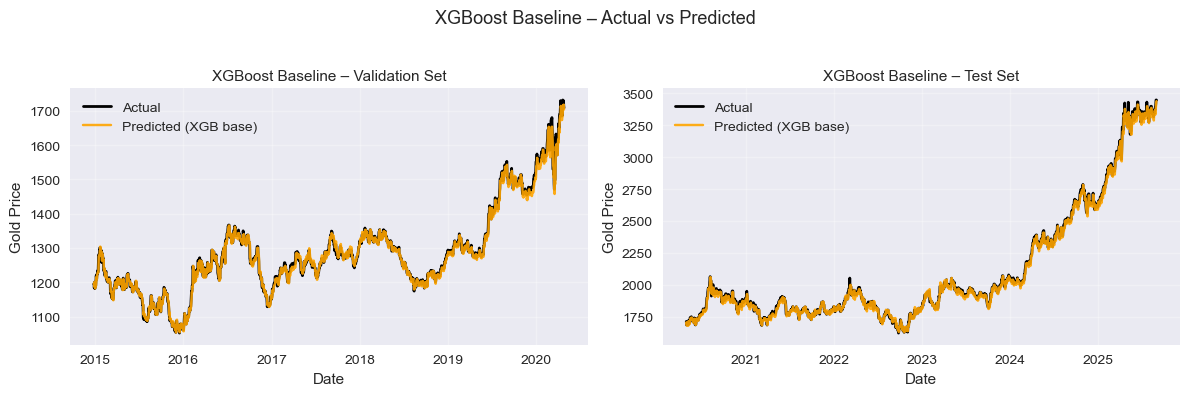

In [162]:
# XGBoost Baseline – untuk slide "EVALUASI AWAL XGBOOST"
plot_model_val_test(
    y_val_true   = y_val_price,
    y_val_pred   = y_val_pred_price_xgb_base,
    y_test_true  = y_test_price,
    y_test_pred  = y_test_pred_price_xgb_base,
    model_name   = "XGBoost",
    version_name = "Baseline",
    pred_label   = "Predicted (XGB base)",
    save_path    = "xgb_baseline_val_test.png"   # atau None kalau cuma mau lihat
)


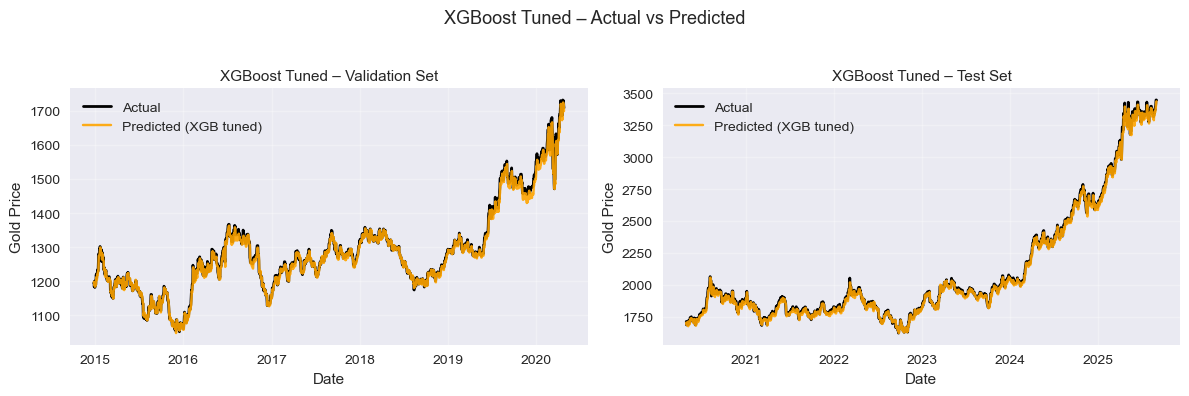

In [164]:
# XGBoost Tuned – untuk slide "XGBOOST SETELAH TUNING"
plot_model_val_test(
    y_val_true   = y_val_price,
    y_val_pred   = y_val_pred_price_xgb_tuned,
    y_test_true  = y_test_price,
    y_test_pred  = y_test_pred_price_xgb_tuned,
    model_name   = "XGBoost",
    version_name = "Tuned",
    pred_label   = "Predicted (XGB tuned)",
    save_path    = "xgb_tuned_val_test.png"
)


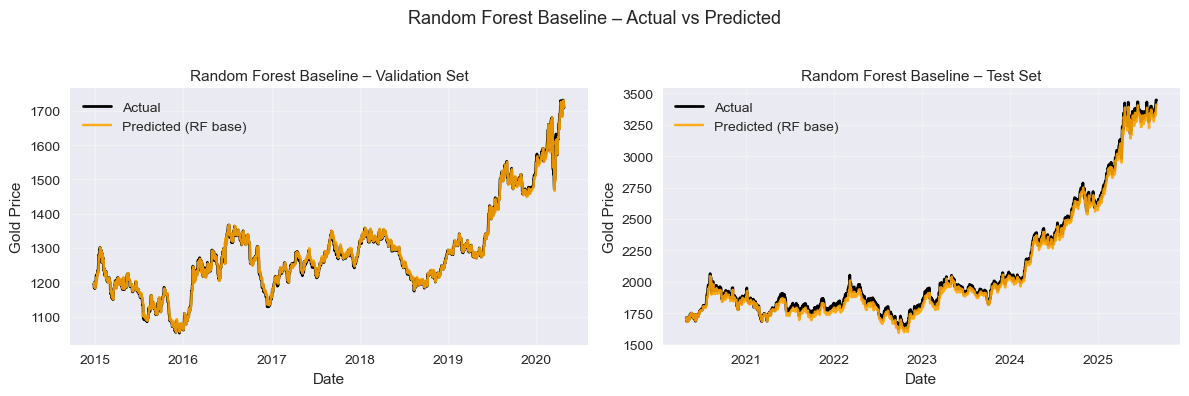

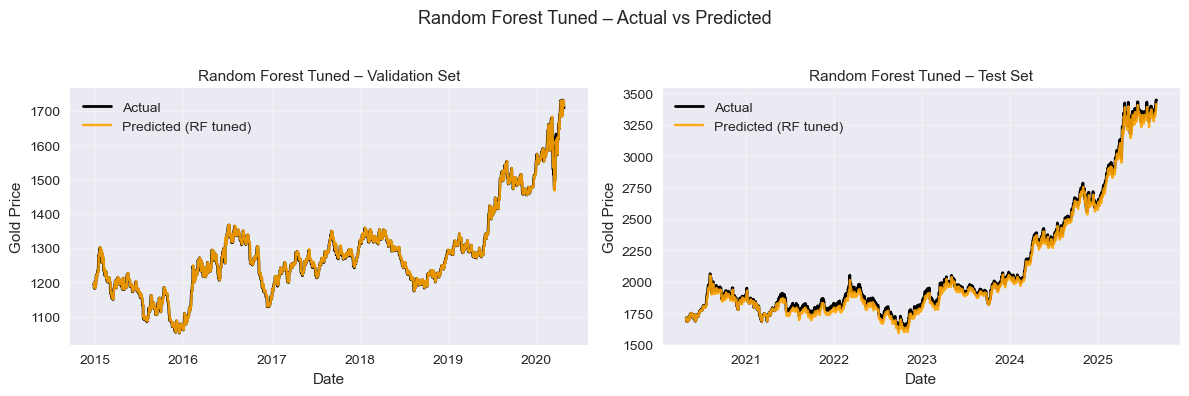

In [166]:
plot_model_val_test(
    y_val_price, y_val_pred_price_rf_base,
    y_test_price, y_test_pred_price_rf_base,
    model_name="Random Forest",
    version_name="Baseline",
    pred_label="Predicted (RF base)",
    save_path="rf_baseline_val_test.png"
)

plot_model_val_test(
    y_val_price, y_val_pred_price_rf_tuned,
    y_test_price, y_test_pred_price_rf_tuned,
    model_name="Random Forest",
    version_name="Tuned",
    pred_label="Predicted (RF tuned)",
    save_path="rf_tuned_val_test.png"
)


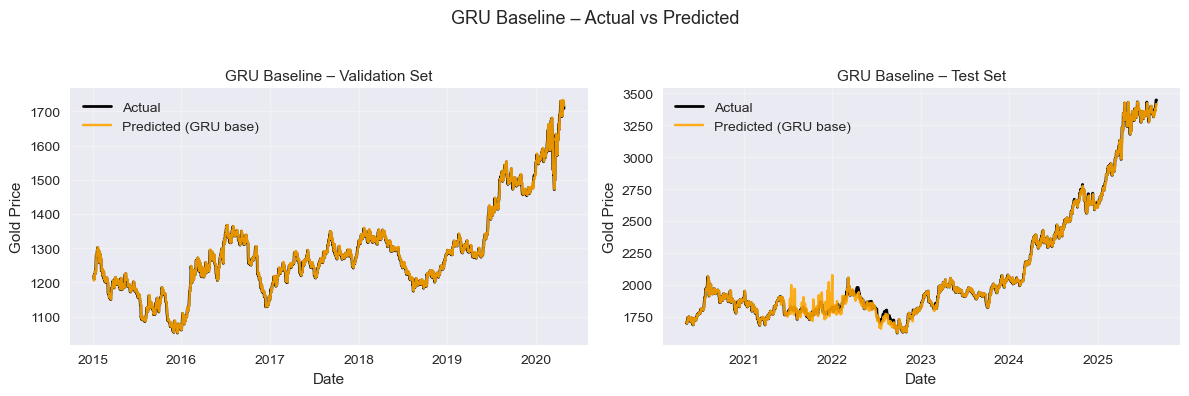

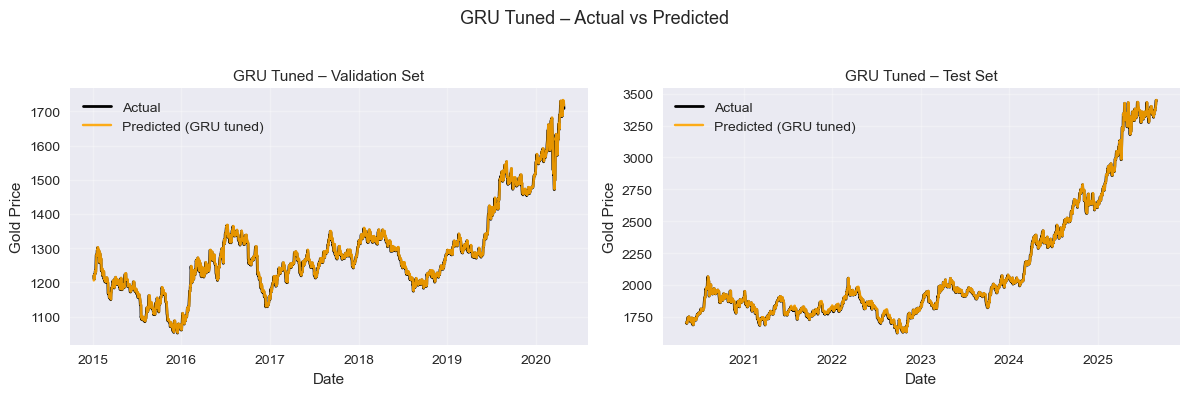

In [168]:
plot_model_val_test(
    y_val_price, y_val_pred_price_gru_base,
    y_test_price, y_test_pred_price_gru_base,
    model_name="GRU",
    version_name="Baseline",
    pred_label="Predicted (GRU base)",
    save_path="gru_baseline_val_test.png"
)

plot_model_val_test(
    y_val_price, y_val_pred_price_gru_tuned,
    y_test_price, y_test_pred_price_gru_tuned,
    model_name="GRU",
    version_name="Tuned",
    pred_label="Predicted (GRU tuned)",
    save_path="gru_tuned_val_test.png"
)


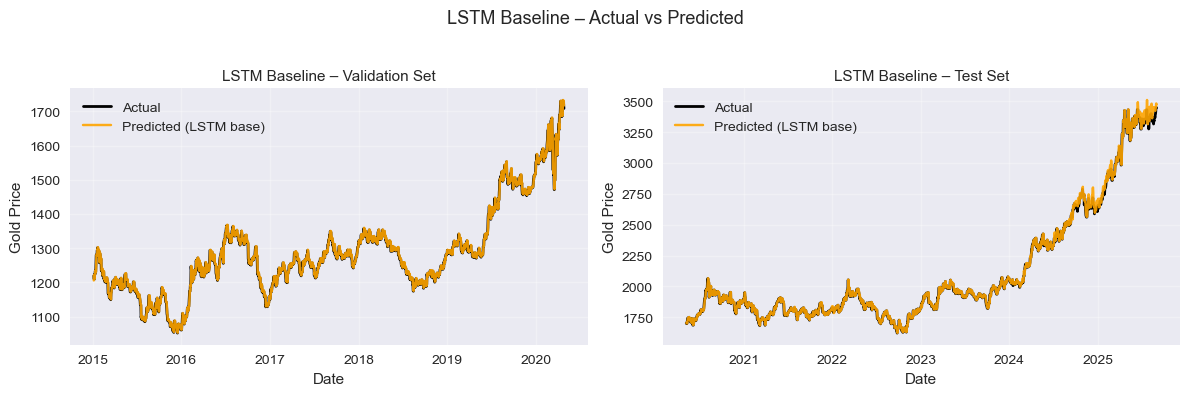

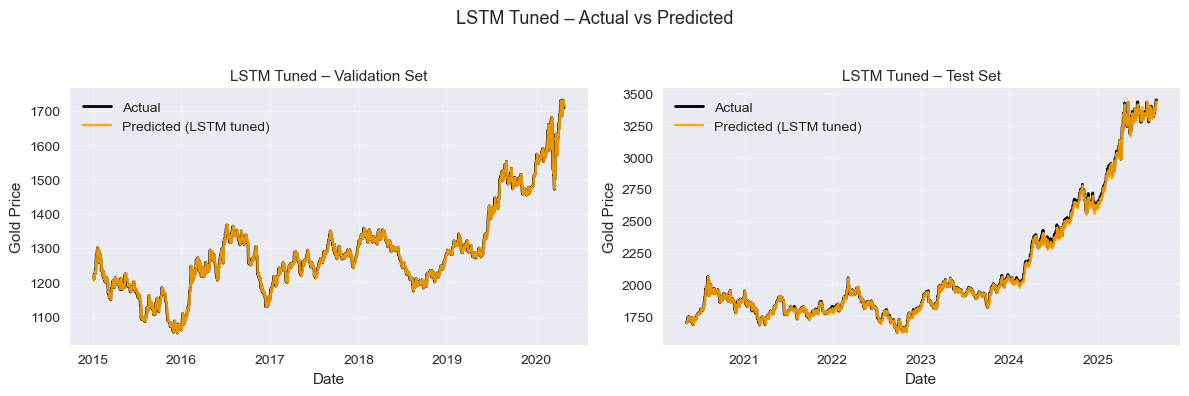

In [170]:
plot_model_val_test(
    y_val_price, y_val_pred_price_lstm_base,
    y_test_price, y_test_pred_price_lstm_base,
    model_name="LSTM",
    version_name="Baseline",
    pred_label="Predicted (LSTM base)",
    save_path="lstm_baseline_val_test.png"
)

plot_model_val_test(
    y_val_price, y_val_pred_price_lstm_tuned,
    y_test_price, y_test_pred_price_lstm_tuned,
    model_name="LSTM",
    version_name="Tuned",
    pred_label="Predicted (LSTM tuned)",
    save_path="lstm_tuned_val_test.png"
)


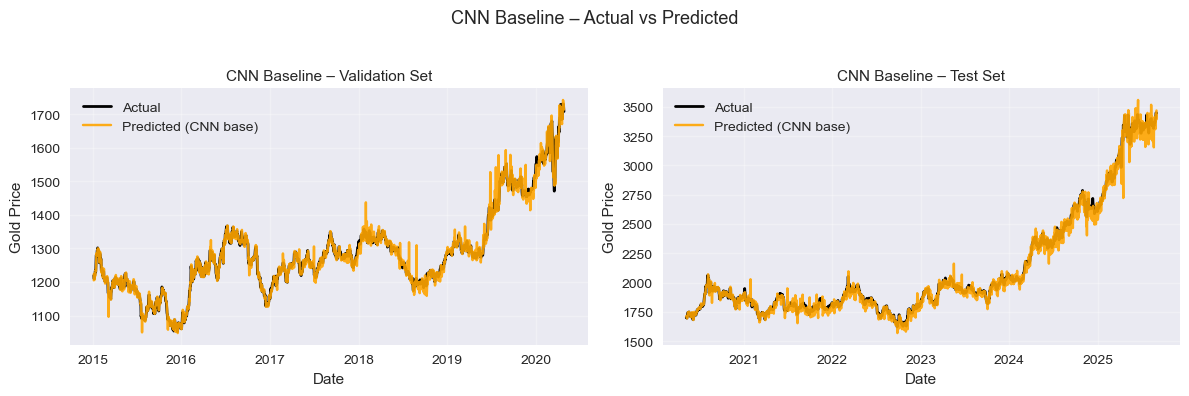

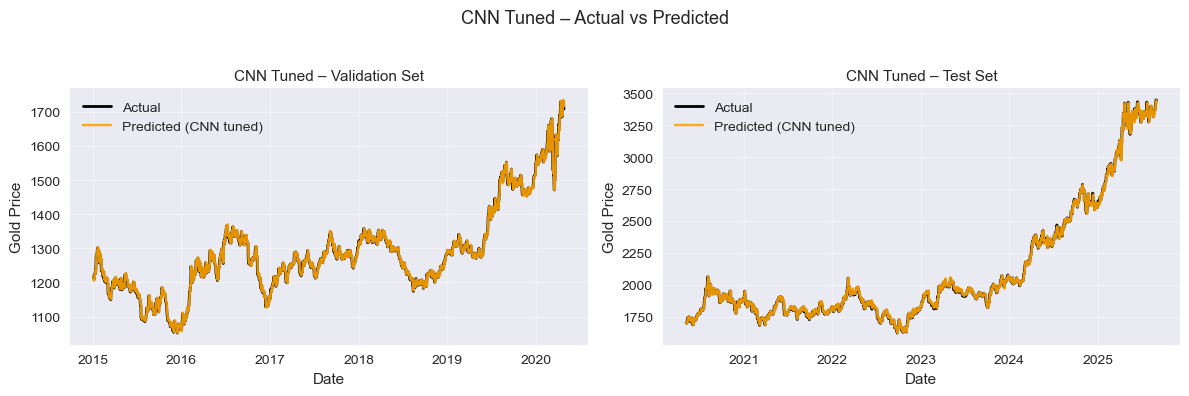

In [172]:
plot_model_val_test(
    y_val_price, y_val_pred_price_cnn_base,
    y_test_price, y_test_pred_price_cnn_base,
    model_name="CNN",
    version_name="Baseline",
    pred_label="Predicted (CNN base)",
    save_path="cnn_baseline_val_test.png"
)

plot_model_val_test(
    y_val_price, y_val_pred_price_cnn_tuned,
    y_test_price, y_test_pred_price_cnn_tuned,
    model_name="CNN",
    version_name="Tuned",
    pred_label="Predicted (CNN tuned)",
    save_path="cnn_tuned_val_test.png"
)


In [124]:
# === BASELINE TEST-SET TABLE ONLY ===

import pandas as pd

baseline_test_rows = [
    {
        "Model": "XGBoost (baseline)",
        "Test_RMSE": metrics_xgb_base_test["rmse"],
        "Test_MAE":  metrics_xgb_base_test["mae"],
        "Test_MAPE": metrics_xgb_base_test["mape"],
    },
    {
        "Model": "Random Forest (baseline)",
        "Test_RMSE": metrics_rf_base_test["rmse"],
        "Test_MAE":  metrics_rf_base_test["mae"],
        "Test_MAPE": metrics_rf_base_test["mape"],
    },
    {
        "Model": "GRU (baseline)",
        "Test_RMSE": metrics_gru_base_test["rmse"],
        "Test_MAE":  metrics_gru_base_test["mae"],
        "Test_MAPE": metrics_gru_base_test["mape"],
    },
    {
        "Model": "LSTM (baseline)",
        "Test_RMSE": metrics_lstm_base_test["rmse"],
        "Test_MAE":  metrics_lstm_base_test["mae"],
        "Test_MAPE": metrics_lstm_base_test["mape"],
    },
    {
        "Model": "CNN (baseline)",
        "Test_RMSE": metrics_cnn_base_test["rmse"],
        "Test_MAE":  metrics_cnn_base_test["mae"],
        "Test_MAPE": metrics_cnn_base_test["mape"],
    },
]

baseline_test_df = pd.DataFrame(baseline_test_rows)

print("=== BASELINE TEST-SET TABLE ===")
display(baseline_test_df)


=== BASELINE TEST-SET TABLE ===


,Model,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (baseline),22.955758,16.368429,0.007625
1,Random Forest (baseline),34.744037,29.695162,0.014248
2,GRU (baseline),27.007567,16.109102,0.007849
3,LSTM (baseline),23.501969,14.189763,0.006244
4,CNN (baseline),46.717692,31.067483,0.014085


Length used for plotting: 1941


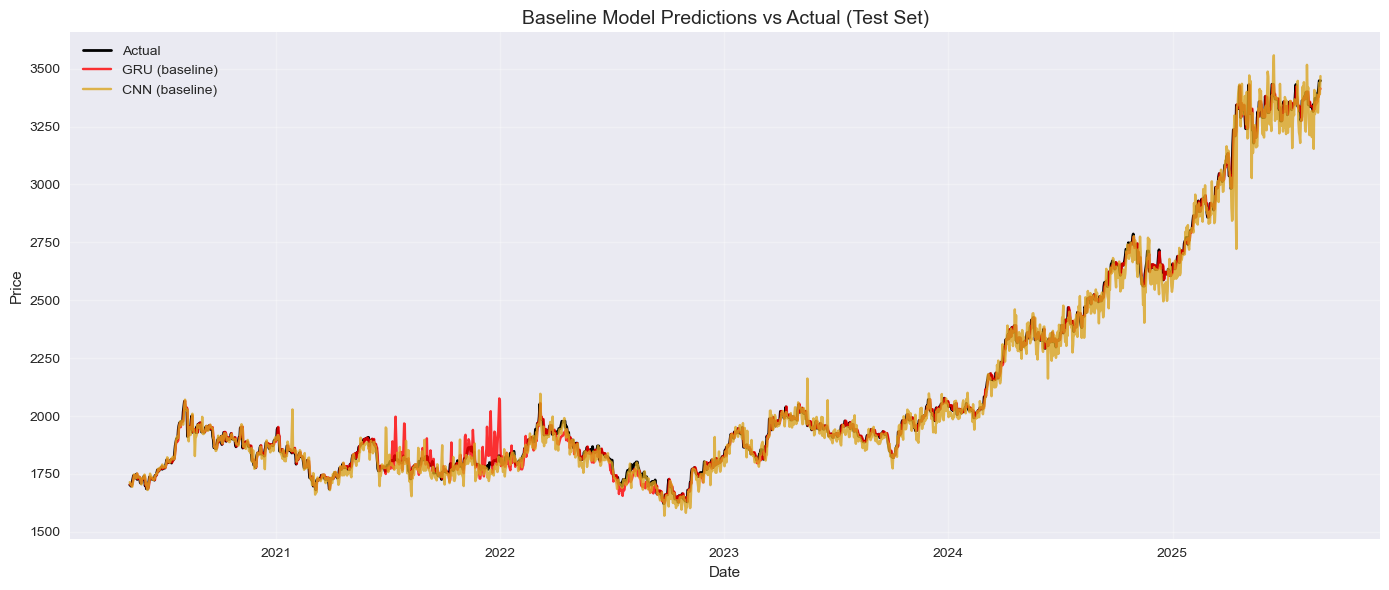

In [140]:
import matplotlib.pyplot as plt

# Tentukan panjang minimal untuk sinkronisasi
lengths = [
    len(y_test_price),
    len(y_test_pred_price_gru_base),
    len(y_test_pred_price_cnn_base)
]

L = min(lengths)
print("Length used for plotting:", L)

# Ambil data akhir sesuai panjang L
dates_plot  = y_test_price.index[-L:]
actual_plot = y_test_price.values[-L:]

gru_plot    = y_test_pred_price_gru_base[-L:]
cnn_plot    = y_test_pred_price_cnn_base[-L:]

# Plot
plt.figure(figsize=(14, 6))

plt.plot(dates_plot, actual_plot, color="black", linewidth=2, 
         label="Actual")
plt.plot(dates_plot, gru_plot, color="red", alpha=0.8, 
         label="GRU (baseline)")
plt.plot(dates_plot, cnn_plot, color="goldenrod", alpha=0.8,
         label="CNN (baseline)")

plt.title("Baseline Model Predictions vs Actual (Test Set)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

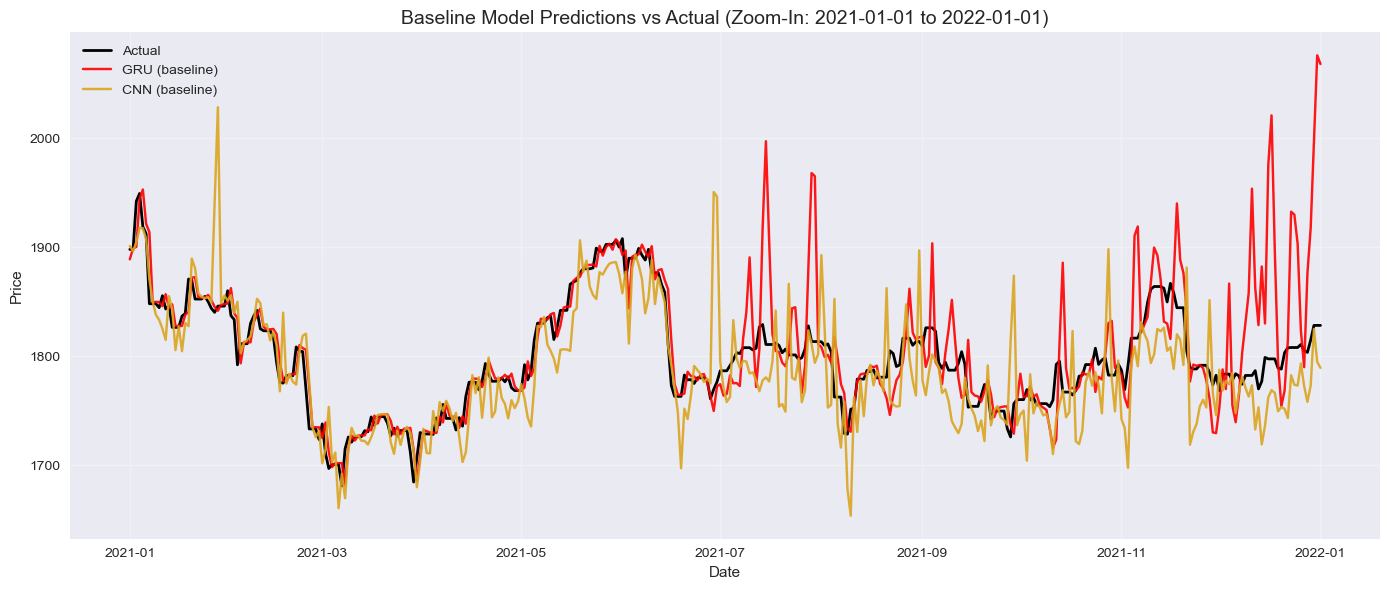

In [142]:
import matplotlib.pyplot as plt

# Tentukan periode zoom-in
start_date = "2021-01-01"
end_date   = "2022-01-01"

# Filter tanggal
mask = (dates_plot >= start_date) & (dates_plot <= end_date)

zoom_dates = dates_plot[mask]
zoom_actual = actual_plot[mask]
zoom_gru = gru_plot[mask]
zoom_cnn = cnn_plot[mask]

plt.figure(figsize=(14, 6))

plt.plot(zoom_dates, zoom_actual, color="black", linewidth=2, label="Actual")
plt.plot(zoom_dates, zoom_gru, color="red", alpha=0.9, label="GRU (baseline)")
plt.plot(zoom_dates, zoom_cnn, color="goldenrod", alpha=0.9, label="CNN (baseline)")

plt.title(f"Baseline Model Predictions vs Actual (Zoom-In: {start_date} to {end_date})", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


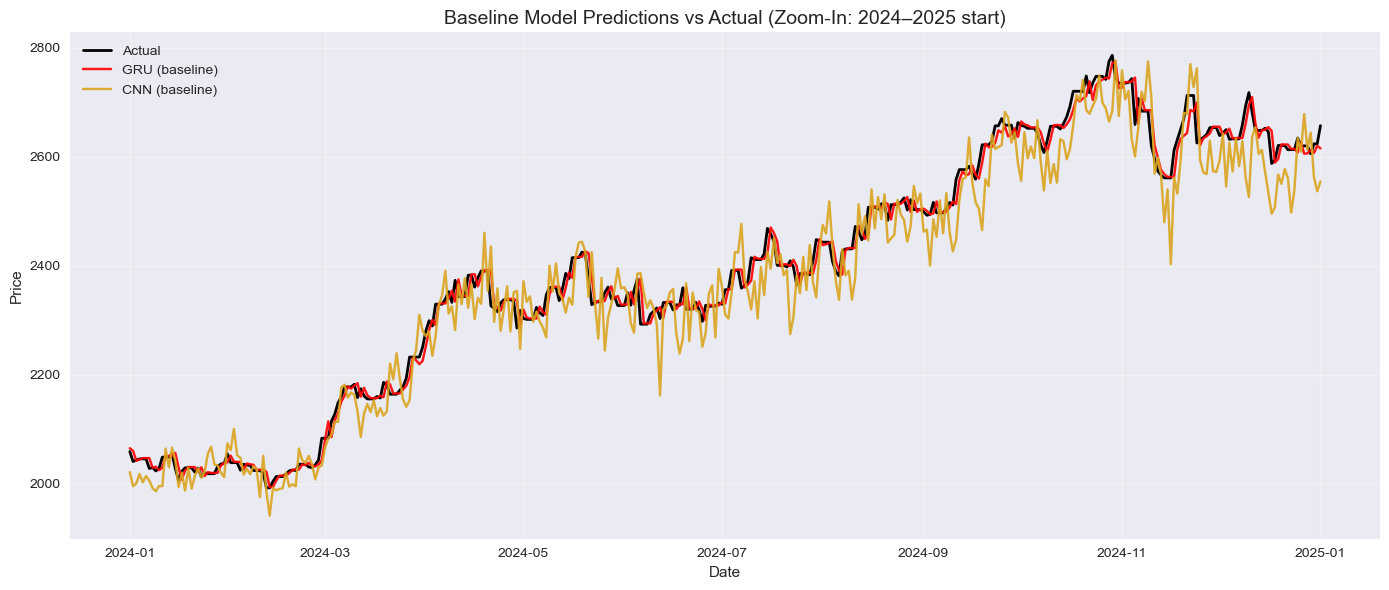

In [148]:
import matplotlib.pyplot as plt

start_date = "2024-01-01"
end_date   = "2025-01-01"

# Mask untuk baseline
mask_base = (dates_plot >= start_date) & (dates_plot <= end_date)

zoom_dates_base  = dates_plot[mask_base]
zoom_actual_base = actual_plot[mask_base]
zoom_gru_base    = gru_plot[mask_base]
zoom_cnn_base    = cnn_plot[mask_base]

plt.figure(figsize=(14, 6))

plt.plot(zoom_dates_base, zoom_actual_base,
         color="black", linewidth=2, label="Actual")
plt.plot(zoom_dates_base, zoom_gru_base,
         color="red", alpha=0.9, label="GRU (baseline)")
plt.plot(zoom_dates_base, zoom_cnn_base,
         color="goldenrod", alpha=0.9, label="CNN (baseline)")

plt.title("Baseline Model Predictions vs Actual (Zoom-In: 2024–2025 start)",
          fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [126]:
# === TUNED TEST-SET TABLE ONLY ===

import pandas as pd

tuned_test_rows = [
    {
        "Model": "XGBoost (tuned)",
        "Test_RMSE": metrics_xgb_tuned_test["rmse"],
        "Test_MAE":  metrics_xgb_tuned_test["mae"],
        "Test_MAPE": metrics_xgb_tuned_test["mape"],
    },
    {
        "Model": "Random Forest (tuned)",
        "Test_RMSE": metrics_rf_tuned_test["rmse"],
        "Test_MAE":  metrics_rf_tuned_test["mae"],
        "Test_MAPE": metrics_rf_tuned_test["mape"],
    },
    {
        "Model": "GRU (tuned)",
        "Test_RMSE": metrics_gru_tuned_test["rmse"],
        "Test_MAE":  metrics_gru_tuned_test["mae"],
        "Test_MAPE": metrics_gru_tuned_test["mape"],
    },
    {
        "Model": "LSTM (tuned)",
        "Test_RMSE": metrics_lstm_tuned_test["rmse"],
        "Test_MAE":  metrics_lstm_tuned_test["mae"],
        "Test_MAPE": metrics_lstm_tuned_test["mape"],
    },
    {
        "Model": "CNN (tuned)",
        "Test_RMSE": metrics_cnn_tuned_test["rmse"],
        "Test_MAE":  metrics_cnn_tuned_test["mae"],
        "Test_MAPE": metrics_cnn_tuned_test["mape"],
    },
]

tuned_test_df = pd.DataFrame(tuned_test_rows)

print("=== TUNED TEST-SET TABLE ===")
display(tuned_test_df)


=== TUNED TEST-SET TABLE ===


,Model,Test_RMSE,Test_MAE,Test_MAPE
0,XGBoost (tuned),23.147438,17.301653,0.008062
1,Random Forest (tuned),33.517169,28.367099,0.013633
2,GRU (tuned),18.214592,11.589836,0.005401
3,LSTM (tuned),20.663068,14.348616,0.006514
4,CNN (tuned),18.620083,12.061127,0.005595


Length used for plotting (tuned): 1941


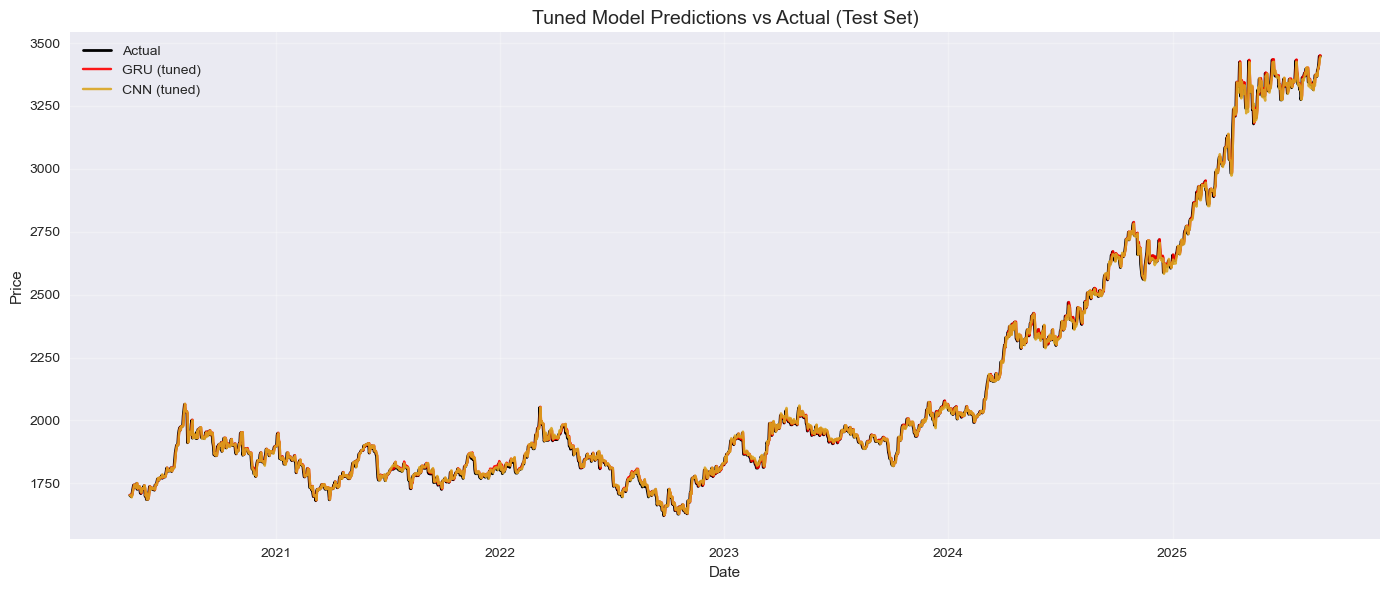

In [144]:
import matplotlib.pyplot as plt

# Sinkronkan panjang data (actual & dua model tuned)
lengths_tuned = [
    len(y_test_price),
    len(y_test_pred_price_gru_tuned),
    len(y_test_pred_price_cnn_tuned),
]

L_tuned = min(lengths_tuned)
print("Length used for plotting (tuned):", L_tuned)

# Ambil L_tuned titik terakhir
dates_tuned   = y_test_price.index[-L_tuned:]
actual_tuned  = y_test_price.values[-L_tuned:]
gru_tuned_pl  = y_test_pred_price_gru_tuned[-L_tuned:]
cnn_tuned_pl  = y_test_pred_price_cnn_tuned[-L_tuned:]

plt.figure(figsize=(14, 6))

plt.plot(dates_tuned, actual_tuned, color="black", linewidth=2, 
         label="Actual")
plt.plot(dates_tuned, gru_tuned_pl, color="red", alpha=0.9, 
         label="GRU (tuned)")
plt.plot(dates_tuned, cnn_tuned_pl, color="goldenrod", alpha=0.9, 
         label="CNN (tuned)")

plt.title("Tuned Model Predictions vs Actual (Test Set)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


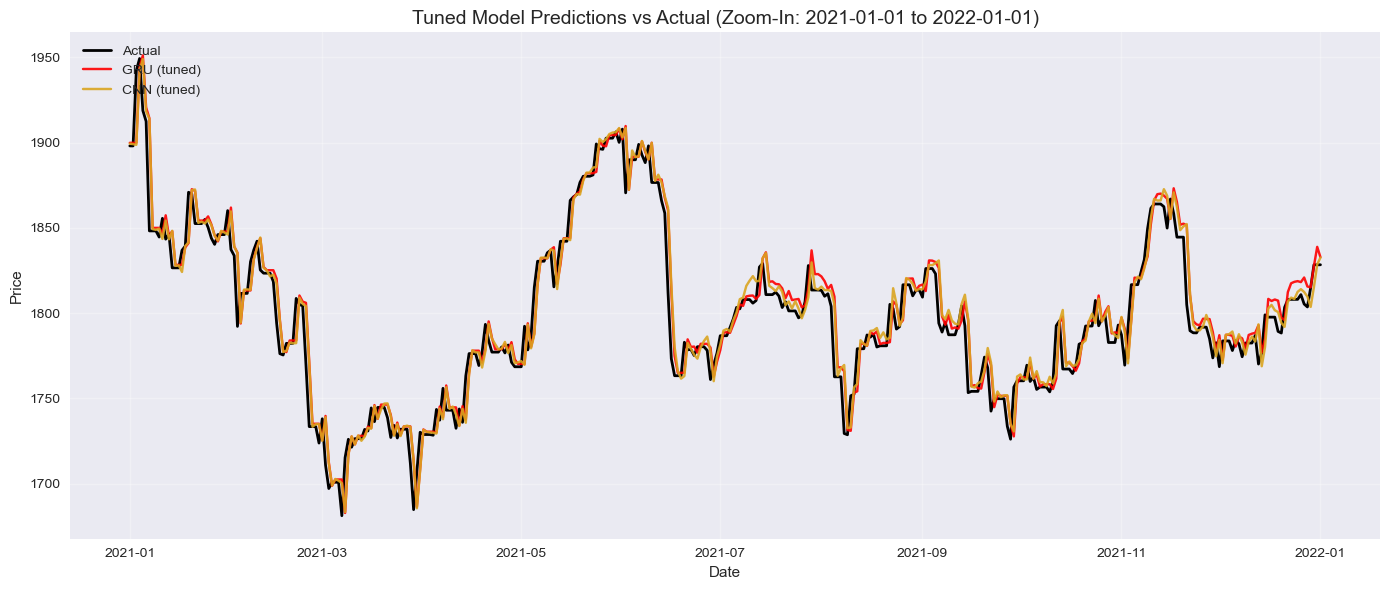

In [146]:
# Periode zoom-in
start_date = "2021-01-01"
end_date   = "2022-01-01"

# Mask untuk filter tanggal
mask_tuned = (dates_tuned >= start_date) & (dates_tuned <= end_date)

zoom_dates_tuned  = dates_tuned[mask_tuned]
zoom_actual_tuned = actual_tuned[mask_tuned]
zoom_gru_tuned    = gru_tuned_pl[mask_tuned]
zoom_cnn_tuned    = cnn_tuned_pl[mask_tuned]

plt.figure(figsize=(14, 6))

plt.plot(zoom_dates_tuned, zoom_actual_tuned, 
         color="black", linewidth=2, label="Actual")
plt.plot(zoom_dates_tuned, zoom_gru_tuned, 
         color="red", alpha=0.9, label="GRU (tuned)")
plt.plot(zoom_dates_tuned, zoom_cnn_tuned, 
         color="goldenrod", alpha=0.9, label="CNN (tuned)")

plt.title(f"Tuned Model Predictions vs Actual (Zoom-In: {start_date} to {end_date})",
          fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


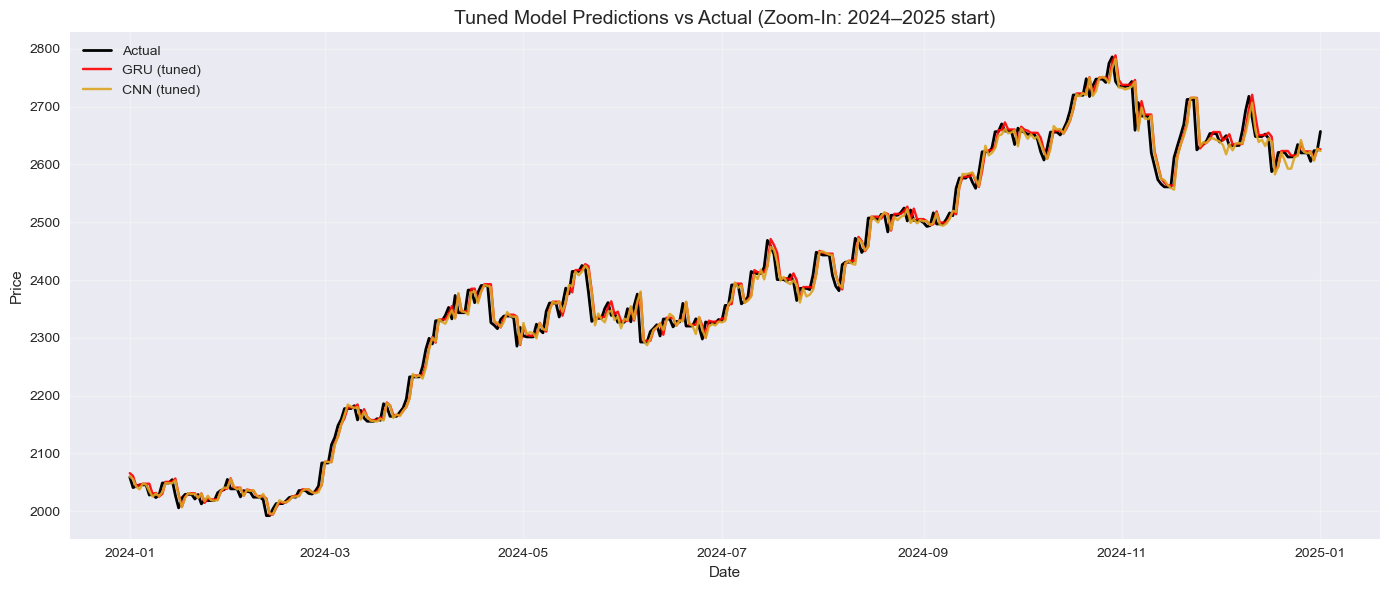

In [150]:
start_date = "2024-01-01"
end_date   = "2025-01-01"

# Mask untuk tuned
mask_tuned = (dates_tuned >= start_date) & (dates_tuned <= end_date)

zoom_dates_tuned  = dates_tuned[mask_tuned]
zoom_actual_tuned = actual_tuned[mask_tuned]
zoom_gru_tuned    = gru_tuned_pl[mask_tuned]
zoom_cnn_tuned    = cnn_tuned_pl[mask_tuned]

plt.figure(figsize=(14, 6))

plt.plot(zoom_dates_tuned, zoom_actual_tuned,
         color="black", linewidth=2, label="Actual")
plt.plot(zoom_dates_tuned, zoom_gru_tuned,
         color="red", alpha=0.9, label="GRU (tuned)")
plt.plot(zoom_dates_tuned, zoom_cnn_tuned,
         color="goldenrod", alpha=0.9, label="CNN (tuned)")

plt.title("Tuned Model Predictions vs Actual (Zoom-In: 2024–2025 start)",
          fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [63]:
# Cell [STACK-1] - STACKING GRU + CNN (tuned)

import numpy as np
from sklearn.linear_model import LinearRegression

# 1) Siapkan meta-features dari prediksi harga GRU & CNN (VAL & TEST)
X_meta_val = np.column_stack([
    y_val_pred_price_gru_tuned,   # prediksi harga dari GRU tuned (Val)
    y_val_pred_price_cnn_tuned    # prediksi harga dari CNN tuned (Val)
])

X_meta_test = np.column_stack([
    y_test_pred_price_gru_tuned,  # prediksi harga dari GRU tuned (Test)
    y_test_pred_price_cnn_tuned   # prediksi harga dari CNN tuned (Test)
])

# Target meta-model = harga aktual
y_meta_val  = y_val_price_seq
y_meta_test = y_test_price_seq

print("Shape X_meta_val :", X_meta_val.shape)
print("Shape X_meta_test:", X_meta_test.shape)

# 2) Meta-learner: Linear Regression (sederhana tapi kuat buat stacking)
stack_model = LinearRegression()

# Train di validation set (supaya nggak leak ke test)
stack_model.fit(X_meta_val, y_meta_val)

# 3) Evaluasi di VAL
y_val_pred_price_stack = stack_model.predict(X_meta_val)
metrics_stack_val = evaluate_regression(
    y_meta_val,
    y_val_pred_price_stack,
    name="Stacking (GRU+CNN tuned, Val)"
)

# 4) Evaluasi di TEST
y_test_pred_price_stack = stack_model.predict(X_meta_test)
metrics_stack_test = evaluate_regression(
    y_meta_test,
    y_test_pred_price_stack,
    name="Stacking (GRU+CNN tuned, Test)"
)


Shape X_meta_val : (1940, 2)
Shape X_meta_test: (1941, 2)
=== Stacking (GRU+CNN tuned, Val) ===
RMSE : 9.2149
MAE  : 5.5871
MAPE : 0.0043

=== Stacking (GRU+CNN tuned, Test) ===
RMSE : 18.1584
MAE  : 11.0907
MAPE : 0.0052



In [66]:
# Cell [STACK-2] - Tabel ringkas hasil Test + Stacking (GRU+CNN tuned)

results_test = [
    {
        "model": "GRU (tuned, Test)",
        "rmse":  metrics_gru_tuned_test["rmse"],
        "mae":   metrics_gru_tuned_test["mae"],
        "mape":  metrics_gru_tuned_test["mape"],
    },
    {
        "model": "Random Forest (tuned, Test)",
        "rmse":  metrics_rf_tuned_test["rmse"],
        "mae":   metrics_rf_tuned_test["mae"],
        "mape":  metrics_rf_tuned_test["mape"],
    },
    {
        "model": "XGBoost (tuned, Test)",
        "rmse":  metrics_xgb_tuned_test["rmse"],
        "mae":   metrics_xgb_tuned_test["mae"],
        "mape":  metrics_xgb_tuned_test["mape"],
    },
    {
        "model": "CNN (tuned, Test)",
        "rmse":  metrics_cnn_tuned_test["rmse"],
        "mae":   metrics_cnn_tuned_test["mae"],
        "mape":  metrics_cnn_tuned_test["mape"],
    },
    {
        "model": "Stacking (GRU+CNN tuned, Test)",
        "rmse":  metrics_stack_test["rmse"],
        "mae":   metrics_stack_test["mae"],
        "mape":  metrics_stack_test["mape"],
    },
]

results_test_df = pd.DataFrame(results_test)
results_test_df


,model,rmse,mae,mape
0,"GRU (tuned, Test)",18.214592,11.589836,0.005401
1,"Random Forest (tuned, Test)",33.517169,28.367099,0.013633
2,"XGBoost (tuned, Test)",23.147438,17.301653,0.008062
3,"CNN (tuned, Test)",18.620083,12.061127,0.005595
4,"Stacking (GRU+CNN tuned, Test)",18.158373,11.090707,0.005158


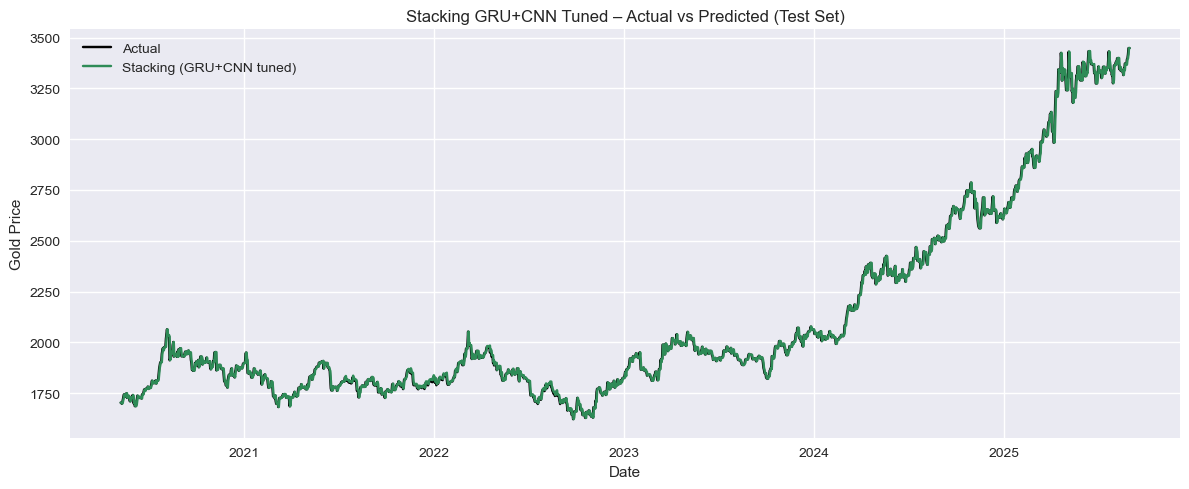

In [180]:
# Cell [STACK-3] - Plot stacking vs actual (Test)

# Index tanggal untuk sequence Test (buang TIME_STEPS pertama)
test_index_seq = y_test_price.index[TIME_STEPS:]

plt.figure(figsize=(12, 5))
plt.plot(test_index_seq, y_test_price_seq, color="black", label="Actual")
plt.plot(test_index_seq, y_test_pred_price_stack, color="seagreen",
         label="Stacking (GRU+CNN tuned)")
plt.title("Stacking GRU+CNN Tuned – Actual vs Predicted (Test Set)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()
plt.show()


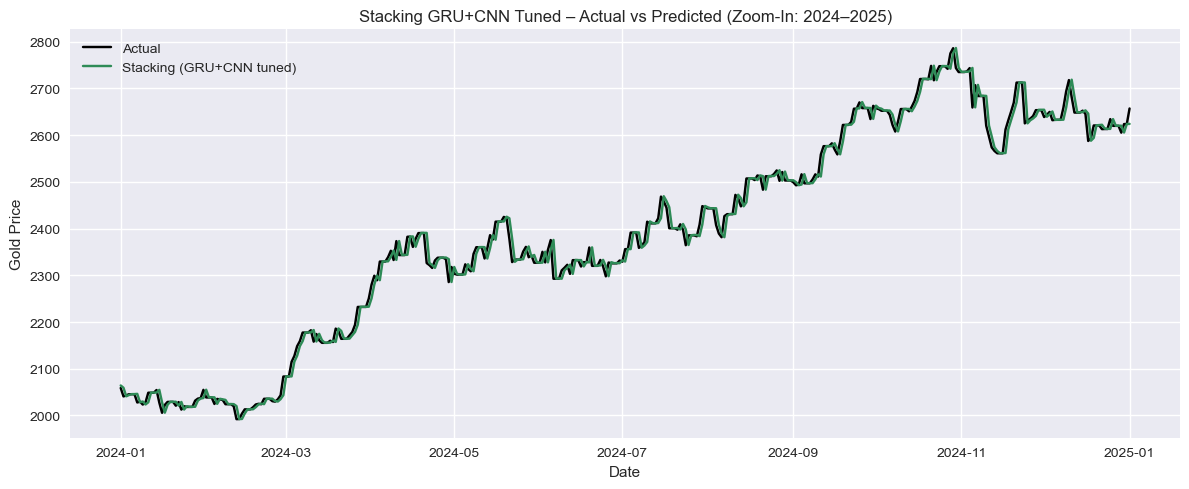

In [182]:
# Cell [STACK-4] - Zoom-in plot Stacking vs Actual (2024–2025)

# Filter rentang waktu zoom
zoom_mask = (test_index_seq >= "2024-01-01") & (test_index_seq <= "2025-01-01")

plt.figure(figsize=(12, 5))
plt.plot(test_index_seq[zoom_mask], y_test_price_seq[zoom_mask],
         color="black", label="Actual")
plt.plot(test_index_seq[zoom_mask], y_test_pred_price_stack[zoom_mask],
         color="seagreen", label="Stacking (GRU+CNN tuned)")
plt.title("Stacking GRU+CNN Tuned – Actual vs Predicted (Zoom-In: 2024–2025)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()
plt.show()


In [70]:
# Cell [XX] - Stacking 3 model (GRU + CNN + LSTM, tuned)

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# 1. Susun meta-feature: prediksi harga dari 3 model (Val dan Test)
X_meta_val_3 = np.column_stack([
    y_val_pred_price_gru_tuned,
    y_val_pred_price_cnn_tuned,
    y_val_pred_price_lstm_tuned,
])

X_meta_test_3 = np.column_stack([
    y_test_pred_price_gru_tuned,
    y_test_pred_price_cnn_tuned,
    y_test_pred_price_lstm_tuned,
])

print("Shape X_meta_val_3 :", X_meta_val_3.shape)
print("Shape X_meta_test_3:", X_meta_test_3.shape)

# 2. Meta-learner (bisa LinearRegression, idenya: belajar nge-blend 3 model)
meta_3 = LinearRegression()

# dilatih di validation set (supaya fair, test tidak disentuh)
meta_3.fit(X_meta_val_3, y_val_price_seq)

# 3. Prediksi stacking di Val dan Test
y_val_pred_price_stack3  = meta_3.predict(X_meta_val_3)
y_test_pred_price_stack3 = meta_3.predict(X_meta_test_3)

# 4. Evaluasi
metrics_stack3_val = evaluate_regression(
    y_val_price_seq,
    y_val_pred_price_stack3,
    name="Stacking (GRU+CNN+LSTM tuned, Val)"
)

metrics_stack3_test = evaluate_regression(
    y_test_price_seq,
    y_test_pred_price_stack3,
    name="Stacking (GRU+CNN+LSTM tuned, Test)"
)

# 5. Tambahkan ke tabel ringkasan results_test_df
row_stack3 = pd.DataFrame([{
    "model": "Stacking (GRU+CNN+LSTM tuned, Test)",
    "rmse":  metrics_stack3_test["rmse"],
    "mae":   metrics_stack3_test["mae"],
    "mape":  metrics_stack3_test["mape"],
}])

results_test_df = pd.concat([results_test_df, row_stack3], ignore_index=True)
display(results_test_df)


Shape X_meta_val_3 : (1940, 3)
Shape X_meta_test_3: (1941, 3)
=== Stacking (GRU+CNN+LSTM tuned, Val) ===
RMSE : 9.2137
MAE  : 5.5883
MAPE : 0.0043

=== Stacking (GRU+CNN+LSTM tuned, Test) ===
RMSE : 18.3102
MAE  : 11.6005
MAPE : 0.0053



,model,rmse,mae,mape
0,"GRU (tuned, Test)",18.214592,11.589836,0.005401
1,"Random Forest (tuned, Test)",33.517169,28.367099,0.013633
2,"XGBoost (tuned, Test)",23.147438,17.301653,0.008062
3,"CNN (tuned, Test)",18.620083,12.061127,0.005595
4,"Stacking (GRU+CNN tuned, Test)",18.158373,11.090707,0.005158
5,"Stacking (GRU+CNN+LSTM tuned, Test)",18.310168,11.600503,0.005345


In [72]:
# === Cell A: FULL SEQUENCE + BASE PREDICTIONS (GRU & CNN) ===

import numpy as np

# 1) Scale ulang seluruh fitur pakai scaler yang sama (fit di train)
X_all_ret_scaled_full = scaler_ret.transform(X_all_ret)   # X_all_ret sudah ada dari feature engineering

# 2) Buat sequence untuk SELURUH data (train+val+test)
X_all_seq, y_all_seq = create_sequences(X_all_ret_scaled_full, y_all_ret, TIME_STEPS)

# 3) Target harga emas besok untuk seluruh sequence
y_all_price_seq = y_all_price.iloc[TIME_STEPS:].values

# 4) Harga hari ini P_t (untuk setiap sequence) dari RET & TARGET_PRICE
P_all = reconstruct_price_from_return(y_all_price, y_all_ret)
P_all_seq = P_all.iloc[TIME_STEPS:].values

# 5) Index tanggal yang sesuai (buang TIME_STEPS pertama)
index_all_seq = df_fs.index[TIME_STEPS:]

print("X_all_seq shape :", X_all_seq.shape)
print("y_all_price_seq :", y_all_price_seq.shape)
print("P_all_seq shape :", P_all_seq.shape)
print("Index length    :", len(index_all_seq))

# 6) Prediksi return GRU & CNN untuk seluruh sequence
y_pred_ret_gru_all  = gru_tuned.predict(X_all_seq).flatten()
y_pred_ret_cnn_all  = cnn_tuned.predict(X_all_seq).flatten()

# 7) Konversi kembali ke level harga
y_pred_price_gru_all = P_all_seq * (1.0 + y_pred_ret_gru_all)
y_pred_price_cnn_all = P_all_seq * (1.0 + y_pred_ret_cnn_all)

# 8) DataFrame fitur meta (GRU & CNN sebagai fitur)
import pandas as pd

df_meta_all = pd.DataFrame({
    "GRU_tuned": y_pred_price_gru_all,
    "CNN_tuned": y_pred_price_cnn_all,
}, index=index_all_seq)

target_all = y_all_price_seq  # harga emas aktual besok

df_meta_all.head()


X_all_seq shape : (12991, 10, 17)
y_all_price_seq : (12991,)
P_all_seq shape : (12991,)
Index length    : 12991
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,GRU_tuned,CNN_tuned
DATE,,
1990-02-05,423.352701,423.233963
1990-02-06,421.901321,421.611447
1990-02-07,418.197798,418.154915
1990-02-08,419.298845,419.518367
1990-02-09,416.396084,416.710442


In [74]:
# === Cell B: ROLLING / WALK-FORWARD STACKING (GRU+CNN tuned) ===

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Gunakan informasi panjang train/val dari sequence yang sudah ada
n_train_seq = len(X_train_seq)
n_val_seq   = len(X_val_seq)
n_test_seq  = len(X_test_seq)

print("n_train_seq:", n_train_seq)
print("n_val_seq  :", n_val_seq)
print("n_test_seq :", n_test_seq)

# Kita mulai rolling dari akhir TRAIN (jadi window pertama = train),
# dan akan merayapi area VAL + TEST.
initial_train_size = n_train_seq    # jumlah titik awal untuk training meta-model
step   = 5                          # lompat 5 hari sekali (biar cepat)
window = 500                        # gunakan 500 hari terakhir sebagai training window (rolling window)

print(f"Total data untuk rolling (sequence): {len(df_meta_all)}")
print(f"Initial train size (seq): {initial_train_size}")
print(f"Step: {step} | Window: {window}")

all_preds = []
all_true  = []
all_dates = []

n_total = len(df_meta_all)

for start in range(initial_train_size, n_total, step):
    end = min(start + step, n_total)
    
    # train window: ambil max(window) poin terakhir sebelum 'start'
    train_start = max(0, start - window)
    
    X_train_meta = df_meta_all.iloc[train_start:start].values
    y_train_meta = target_all[train_start:start]
    
    X_test_meta  = df_meta_all.iloc[start:end].values
    y_test_meta  = target_all[start:end]
    dates_chunk  = df_meta_all.index[start:end]
    
    # kalau tidak cukup data train, lompat
    if len(X_train_meta) < 50 or len(X_test_meta) == 0:
        continue
    
    # fit meta-model (Linear Regression)
    meta_model_roll = LinearRegression()
    meta_model_roll.fit(X_train_meta, y_train_meta)
    
    # prediksi blok berikutnya
    y_pred_chunk = meta_model_roll.predict(X_test_meta)
    
    all_preds.append(y_pred_chunk)
    all_true.append(y_test_meta)
    all_dates.append(dates_chunk)

# Gabungkan semua chunk
y_true_roll = np.concatenate(all_true)
y_pred_roll = np.concatenate(all_preds)
dates_roll  = np.concatenate(all_dates)

print("Total poin evaluasi rolling :", len(y_true_roll))

# Hitung metrik rolling dengan fungsi yang sama
metrics_stacking_roll = evaluate_regression(
    y_true_roll,
    y_pred_roll,
    name="Stacking (GRU+CNN tuned, Rolling)"
)
metrics_stacking_roll


n_train_seq: 9090
n_val_seq  : 1940
n_test_seq : 1941
Total data untuk rolling (sequence): 12991
Initial train size (seq): 9090
Step: 5 | Window: 500
Total poin evaluasi rolling : 3901
=== Stacking (GRU+CNN tuned, Rolling) ===
RMSE : 14.4573
MAE  : 8.5447
MAPE : 0.0049



{'model': 'Stacking (GRU+CNN tuned, Rolling)',
 'rmse': 14.457300403035095,
 'mae': 8.544669696811406,
 'mape': 0.004854597637729694}

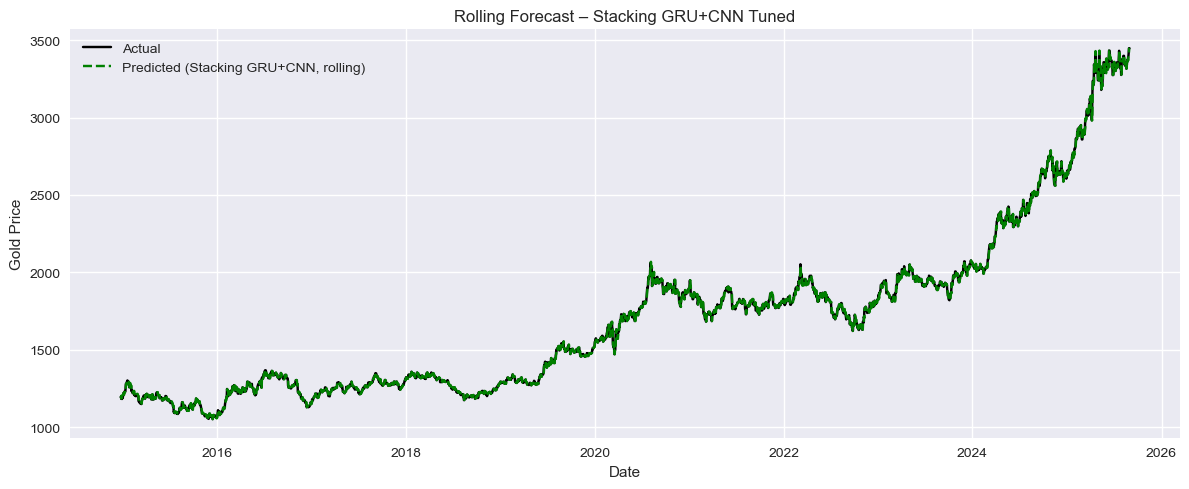

In [186]:
# === Cell C: Plot Rolling Forecast – Stacking (GRU+CNN tuned) ===

plt.figure(figsize=(12, 5))
plt.plot(dates_roll, y_true_roll, color="black", label="Actual")
plt.plot(dates_roll, y_pred_roll, color="green", linestyle="--",
         label="Predicted (Stacking GRU+CNN, rolling)")
plt.title("Rolling Forecast – Stacking GRU+CNN Tuned")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()
plt.show()


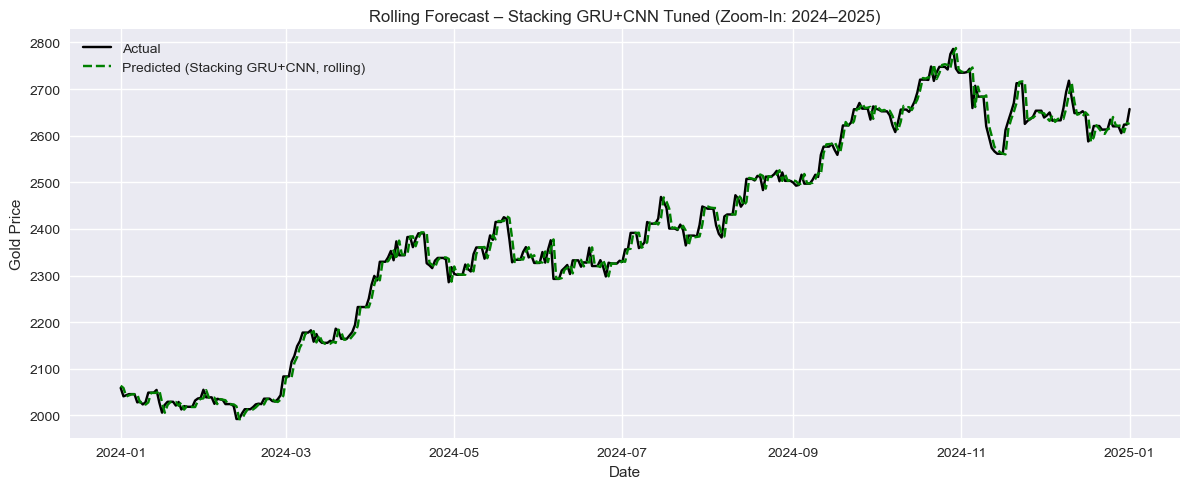

In [190]:
dates_roll_dt = pd.to_datetime(dates_roll)

zoom_mask = (dates_roll_dt >= "2024-01-01") & (dates_roll_dt <= "2025-01-01")

plt.figure(figsize=(12, 5))
plt.plot(dates_roll_dt[zoom_mask], y_true_roll[zoom_mask], color="black", label="Actual")
plt.plot(dates_roll_dt[zoom_mask], y_pred_roll[zoom_mask], color="green", linestyle="--",
         label="Predicted (Stacking GRU+CNN, rolling)")
plt.title("Rolling Forecast – Stacking GRU+CNN Tuned (Zoom-In: 2024–2025)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.tight_layout()
plt.show()


Stacking coefficients (GRU, CNN): [ 1.04011065 -0.04106204]


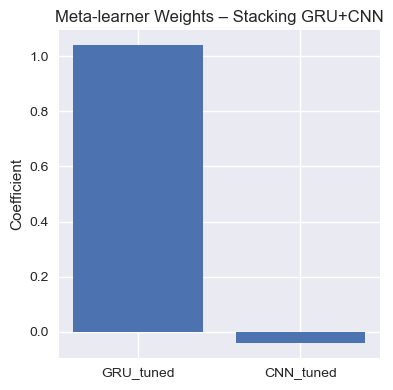

In [94]:
# Cell [XAI-1] - Kontribusi GRU vs CNN di Stacking (Linear Regression)

import numpy as np
import matplotlib.pyplot as plt

coefs = stack_model.coef_   # jika input meta = [GRU, CNN] → shape (2,)

print("Stacking coefficients (GRU, CNN):", coefs)

labels = ["GRU_tuned", "CNN_tuned"]

plt.figure(figsize=(4, 4))
plt.bar(labels, coefs)
plt.title("Meta-learner Weights – Stacking GRU+CNN")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()


In [194]:
import pandas as pd

coefs = stack_model.coef_
labels = ["GRU_tuned", "CNN_tuned"]

df_coef = pd.DataFrame({
    "Component": labels,
    "Coefficient": coefs,
    "Interpretation": [
        "Dominant contributor; captures long-term patterns",
        "Minor corrective effect; adjusts short-term noise"
    ]
})

df_coef


,Component,Coefficient,Interpretation
0,GRU_tuned,1.040111,Dominant contributor; captures long-term patterns
1,CNN_tuned,-0.041062,Minor corrective effect; adjusts short-term noise


In [96]:
# recap (kamu kemungkinan sudah punya ini):
X_meta_val = np.column_stack([
    y_val_pred_price_gru_tuned,
    y_val_pred_price_cnn_tuned
])
stack_model.fit(X_meta_val, y_val_price_seq)
y_val_pred_price_stack = stack_model.predict(X_meta_val)


In [98]:
# Cell [XAI-2] - Install & import SHAP untuk surrogate model

# Kalau shap belum ada, uncomment dan jalankan sekali:
# !pip install shap

import shap
shap.initjs()


X_val_ret_scaled: (1950, 17)
y_val_price    : (1950,)
y_surrogate (stack Val): (1940,)
X_val_surr shape: (1940, 17)
y_surrogate shape: (1940,)
Top 20 fitur menurut surrogate XGBoost (Stacking GRU+CNN):


,feature,importance
0,GOLD_CLOSE,0.406665
2,SP500,0.218666
6,TREASURY_10Y,0.136652
5,CPI_ACTUAL,0.101570
7,REAL_YIELD,0.066725
4,FED_FUNDS,0.034415
14,MONTH,0.020403
1,WTI,0.012976
3,VIX,0.000692
10,RET_PAST_5,0.000463


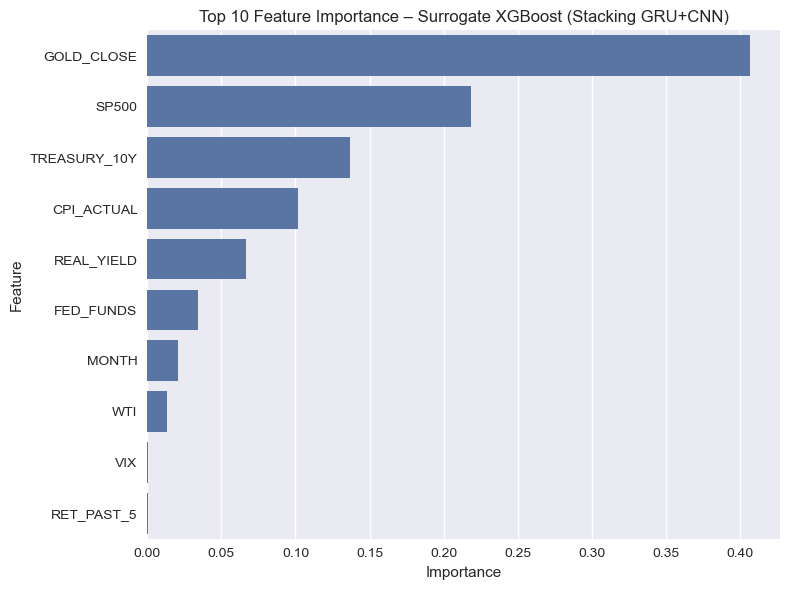

In [102]:
# Cell [XAI-3] - Surrogate XGBoost untuk menjelaskan Stacking GRU+CNN (FIX ALIGN)

from xgboost import XGBRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Pastikan variabel ini sudah ada:
# - X_val_ret_scaled : numpy array, shape (n_val_days, n_features)
# - y_val_price      : Series harga emas (Val), index = tanggal
# - TIME_STEPS       : int, misal 10
# - y_val_pred_price_stack : prediksi harga dari stacking (Val), length = len(y_val_price_seq)
# - feature_cols_ret : list nama fitur, length = n_features

print("X_val_ret_scaled:", X_val_ret_scaled.shape)
print("y_val_price    :", y_val_price.shape)
print("y_surrogate (stack Val):", y_val_pred_price_stack.shape)

# 1. Buat DataFrame fitur Val dengan index tanggal
X_val_df = pd.DataFrame(
    X_val_ret_scaled,
    index=y_val_price.index,
    columns=feature_cols_ret
)

# 2. Index yang dipakai oleh model sekuensial (GRU/CNN/Stacking)
val_index_seq = y_val_price.index[TIME_STEPS:]   # sama seperti yang dipakai untuk y_val_price_seq

# 3. Ambil hanya baris fitur yang align dengan sequence
X_val_surr = X_val_df.loc[val_index_seq].values
y_surrogate = y_val_pred_price_stack             # panjangnya harus = len(val_index_seq)

print("X_val_surr shape:", X_val_surr.shape)
print("y_surrogate shape:", y_surrogate.shape)

# 4. Latih surrogate XGBoost
xgb_surr = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
)

xgb_surr.fit(X_val_surr, y_surrogate)

# 5. Feature importance (global) surrogate
fi_surr = pd.DataFrame({
    "feature": feature_cols_ret,
    "importance": xgb_surr.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 20 fitur menurut surrogate XGBoost (Stacking GRU+CNN):")
display(fi_surr.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(
    data=fi_surr.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 Feature Importance – Surrogate XGBoost (Stacking GRU+CNN)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


C:\Users\totti\AppData\Local\Temp\ipykernel_11488\4031804756.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


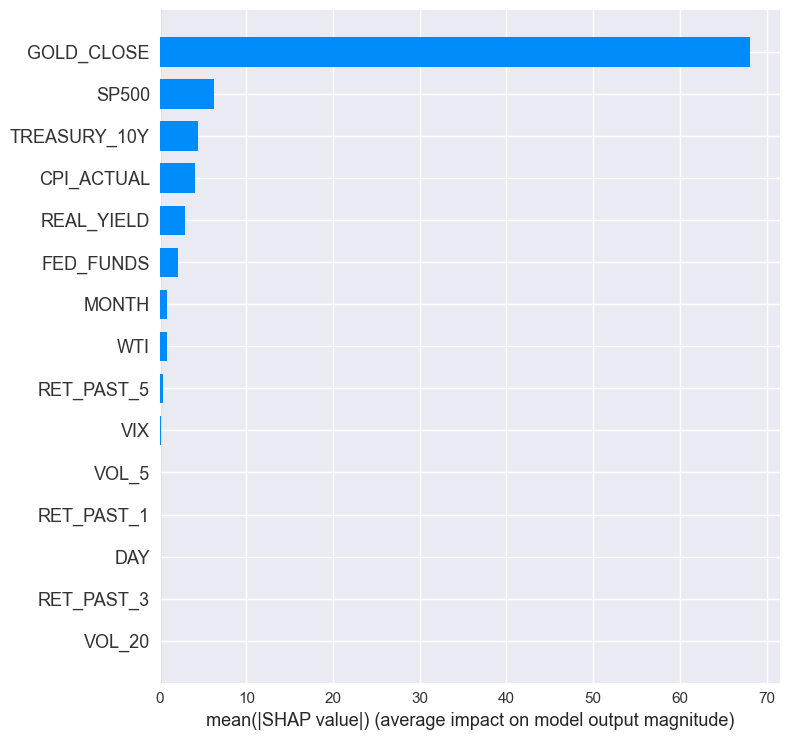

In [104]:
# Cell [XAI-4] - SHAP TreeExplainer untuk Surrogate Stacking (pakai X_val_surr)

import shap
shap.initjs()

# Pakai sebagian sampel supaya ringan
X_sample = X_val_surr[:1000]

explainer_surr = shap.TreeExplainer(xgb_surr)
shap_values_surr = explainer_surr.shap_values(X_sample)

shap.summary_plot(
    shap_values_surr,
    X_sample,
    feature_names=feature_cols_ret,
    plot_type="bar",
    max_display=15
)


In [106]:
# === RESIDUAL DIAGNOSTICS – STACKING GRU+CNN (TEST) ===

import numpy as np
import pandas as pd

# Residual = actual - predicted
resid_stack = y_test_price_seq - y_test_pred_price_stack

resid_df = pd.DataFrame({
    "DATE": test_index_seq,
    "actual_price": y_test_price_seq,
    "pred_price"  : y_test_pred_price_stack,
    "residual"    : resid_stack,
}).set_index("DATE")

print("Residual summary (Stacking GRU+CNN, Test):")
print(resid_df["residual"].describe())
resid_df.head()


Residual summary (Stacking GRU+CNN, Test):
count    1941.000000
mean        0.058373
std        18.162958
min      -116.327247
25%        -5.987598
50%        -0.261695
75%         6.383774
max       115.222144
Name: residual, dtype: float64


,actual_price,pred_price,residual
DATE,,,
2020-05-08,1702.65,1702.982039,-0.332039
2020-05-09,1702.65,1702.970542,-0.320542
2020-05-10,1697.35,1702.942426,-5.592426
2020-05-11,1702.72,1697.776637,4.943363
2020-05-12,1715.99,1703.052527,12.937473


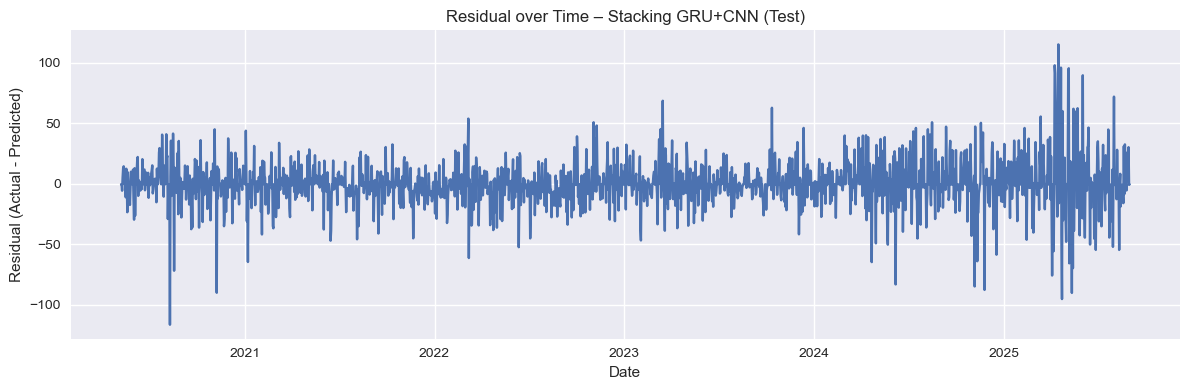

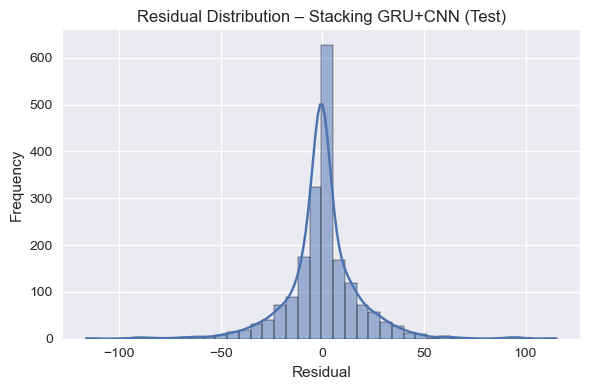

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# 1) Residual vs time
plt.figure(figsize=(12, 4))
plt.plot(resid_df.index, resid_df["residual"])
plt.title("Residual over Time – Stacking GRU+CNN (Test)")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

# 2) Histogram + KDE
plt.figure(figsize=(6, 4))
sns.histplot(resid_df["residual"], bins=40, kde=True)
plt.title("Residual Distribution – Stacking GRU+CNN (Test)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


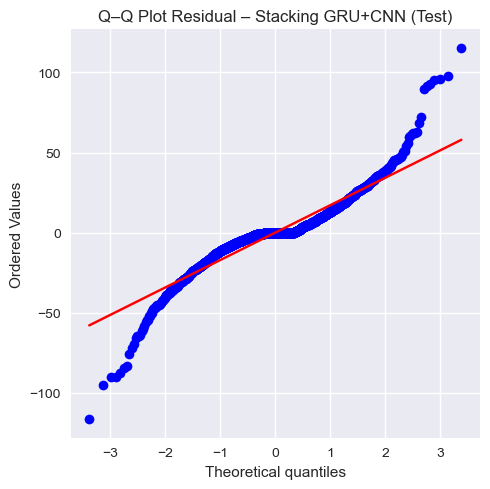

<Figure size 600x400 with 0 Axes>

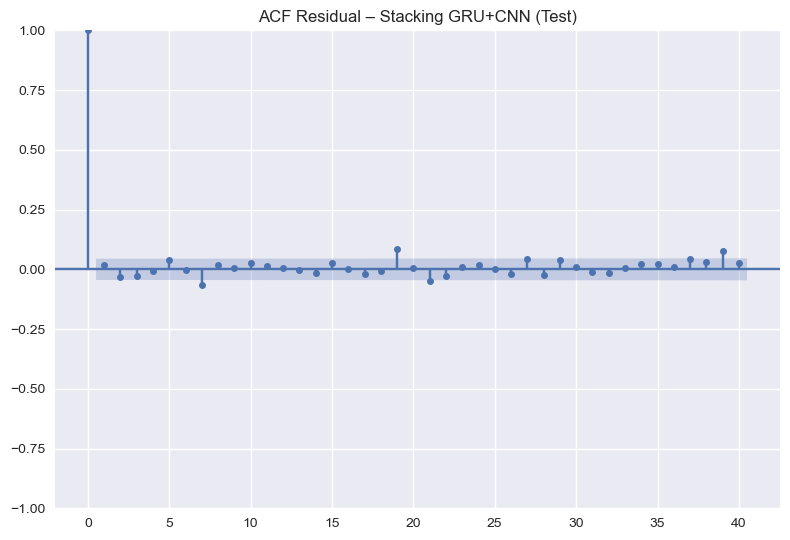

In [110]:
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# 3) Q–Q plot (cek normalitas)
plt.figure(figsize=(5, 5))
stats.probplot(resid_df["residual"], dist="norm", plot=plt)
plt.title("Q–Q Plot Residual – Stacking GRU+CNN (Test)")
plt.tight_layout()
plt.show()

# 4) Autocorrelation Function (ACF)
plt.figure(figsize=(6, 4))
plot_acf(resid_df["residual"], lags=40)
plt.title("ACF Residual – Stacking GRU+CNN (Test)")
plt.tight_layout()
plt.show()


In [118]:
# Cell [DM-1] - Diebold-Mariano test helper

import numpy as np
from math import sqrt
from scipy.stats import norm

def dm_test(e1, e2, h=1, power=2):
    """
    Diebold-Mariano test untuk membandingkan akurasi dua model.
    
    e1, e2 : array errors (actual - pred) untuk model 1 dan model 2
    h      : forecasting horizon (kita pakai 1 -> one-step ahead)
    power  : 1 = absolute error, 2 = squared error (umum dipakai)

    Return: (DM_stat, p_value)
    """
    e1 = np.asarray(e1)
    e2 = np.asarray(e2)
    assert e1.shape == e2.shape, "Error series harus punya panjang yang sama!"

    # loss series
    if power == 1:
        L1 = np.abs(e1)
        L2 = np.abs(e2)
    else:  # power=2, squared error
        L1 = e1**2
        L2 = e2**2

    d = L1 - L2              # differential loss
    T = d.shape[0]
    d_bar = d.mean()

    # Newey-West variance estimator (untuk general h),
    # di kasus kita h=1 -> cuma var biasa
    if h == 1:
        var_d = d.var(ddof=1)
    else:
        d_mean = d_bar
        gamma0 = np.sum((d - d_mean)**2) / T
        var_d = gamma0
        for lag in range(1, h):
            gamma = np.sum((d[:-lag] - d_mean)*(d[lag:] - d_mean)) / T
            var_d += 2 * (1 - lag / h) * gamma

    dm_stat = d_bar / sqrt(var_d / T)
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))  # two-sided

    return dm_stat, p_value


In [120]:
# Cell [DM-2] - Susun error series untuk DM test

# pastikan semua jadi numpy array dan align panjangnya
y_true_test = np.asarray(y_test_price_seq)

e_stack = y_true_test - np.asarray(y_test_pred_price_stack)
e_gru   = y_true_test - np.asarray(y_test_pred_price_gru_tuned)
e_cnn   = y_true_test - np.asarray(y_test_pred_price_cnn_tuned)
# kalau mau: e_xgb = y_true_test - np.asarray(y_test_pred_price_xgb_tuned)

print("Len errors - stack, gru, cnn:", len(e_stack), len(e_gru), len(e_cnn))


Len errors - stack, gru, cnn: 1941 1941 1941


In [122]:
# Cell [DM-3] - DM test comparisons (power=2 -> squared error)

# 1) Stacking vs GRU
dm_stack_gru, p_stack_gru = dm_test(e_stack, e_gru, h=1, power=2)
print("DM test (Stacking vs GRU, Test, SE):")
print(f"  DM stat : {dm_stack_gru:.3f}")
print(f"  p-value : {p_stack_gru:.4f}\n")

# 2) Stacking vs CNN
dm_stack_cnn, p_stack_cnn = dm_test(e_stack, e_cnn, h=1, power=2)
print("DM test (Stacking vs CNN, Test, SE):")
print(f"  DM stat : {dm_stack_cnn:.3f}")
print(f"  p-value : {p_stack_cnn:.4f}\n")

# (opsional) 3) GRU vs CNN
dm_gru_cnn, p_gru_cnn = dm_test(e_gru, e_cnn, h=1, power=2)
print("DM test (GRU vs CNN, Test, SE):")
print(f"  DM stat : {dm_gru_cnn:.3f}")
print(f"  p-value : {p_gru_cnn:.4f}")


DM test (Stacking vs GRU, Test, SE):
  DM stat : -1.197
  p-value : 0.2314

DM test (Stacking vs CNN, Test, SE):
  DM stat : -3.520
  p-value : 0.0004

DM test (GRU vs CNN, Test, SE):
  DM stat : -2.847
  p-value : 0.0044


In [198]:
!pip install pydot graphviz

In [202]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense
from tensorflow.keras.utils import plot_model

TIME_STEPS = 10
N_FEATURES = X_train_ret_scaled.shape[1]

model_gru = Sequential([
    Input(shape=(TIME_STEPS, N_FEATURES)),
    GRU(64),
    Dense(1)
])

plot_model(
    model_gru,
    to_file="GRU_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=200
)


You must install pydot (`pip install pydot`) for `plot_model` to work.
